# Attribution and sensitivity analyses

This notebook estimates how weather-normalised monthly PM2.5 changed in Paris relative to Lyon and Marseille. The complete data window is 2013-2025, while the main comparison ends in August 2022 because both comparator cities introduced their own restrictions in September 2022.

The notebook contains the pre-treatment checks, the main panel estimate, a fleet-dose model, sensitivity analyses, false-onset tests, roadside comparisons and minimum detectable effects. These pieces answer different questions and are not treated as interchangeable evidence.

Run the notebook from a fresh kernel, from top to bottom. `MODE = "normalised"` uses the weather-adjusted series; `MODE = "raw"` repeats the calculations on observed concentrations for comparison. The cross-city estimates are conditional on the fitted weather models and depend on the assumptions discussed below.


## Method and data references

- Grange, S. K., Carslaw, D. C., Lewis, A. C., Boleti, E. and Hueglin, C. (2018), *Random forest meteorological normalisation models for Swiss PM10 trend analysis*, Atmospheric Chemistry and Physics 18, 6223-6239. https://doi.org/10.5194/acp-18-6223-2018
- Grange, S. K. and Carslaw, D. C. (2019), *Using meteorological normalisation to detect interventions in air quality time series*, Science of the Total Environment 653, 578-588. https://doi.org/10.1016/j.scitotenv.2018.10.344. Open accepted manuscript: https://eprints.whiterose.ac.uk/id/eprint/138077/1/meteorological_normalisation_article_markup.pdf
- Driscoll, J. C. and Kraay, A. C. (1998), *Consistent covariance matrix estimation with spatially dependent panel data*, Review of Economics and Statistics 80(4), 549-560. https://doi.org/10.1162/003465398557825. Hoechle, D. (2007), *Robust standard errors for panel regressions with cross-sectional dependence*, Stata Journal 7(3), 281-312. Open copy: https://ageconsearch.umn.edu/record/119278/files/sjart_st0128.pdf
- Python implementation of the panel model and Driscoll-Kraay covariance: `linearmodels.panel.PanelOLS`. https://bashtage.github.io/linearmodels/panel/panel/linearmodels.panel.model.PanelOLS.fit.html
- SDES communal vehicle-register data. https://www.data.gouv.fr/datasets/parc-de-vehicules-routiers
- Official policy sources used for the dates and restriction sets: Paris consultation dossier, https://www.api-site.paris.fr/paris/public/2019%2F3%2FDossier%20de%20consultation%20ZCR%20Version%20finale.pdf; Metropole du Grand Paris ZFE history, https://www.metropolegrandparis.fr/fr/actualites/zfe-la-metropole-du-grand-paris-prepare-activement-le-passage-au-critair-3-au-1er; Metropole de Lyon documentation, https://zfe.grandlyon.com/documentation/; Marseille order 22/131/CM, linked from https://data.ampmetropole.fr/explore/dataset/voies-exceptionnelles-zfe-m-marseille/table/.
- The surrounding-area section also uses the Greater Paris FAQ, which explains that the original metropolitan timetable required local mayoral orders and could be delayed by commune: https://metropolegrandparis.fr/sites/default/files/media/document/3_ANNEXE%20_2_Foire%20aux%20questions.pdf. Local evidence is recorded for Gennevilliers, https://www.ville-gennevilliers.fr/598/citoyennete/participer/consultations-citoyennes/consultation-zone-a-faibles-emissions-zfe.htm; Puteaux, https://www.puteaux.fr/cadre-de-vie/developpement-durable/zone-a-faibles-emissions/; Vitry-sur-Seine, https://www.vitry94.fr/app/uploads/2025/11/vitry94_lemensuel191-fevrier2022.pdf; and Bobigny, https://www.bobigny.fr/fileadmin/images/PDF/Conseils_municipaux_et_Actes_Administratifs/CM_2023/CM_du_09.02.2023/02_090223_Rapport_sur_la_situation_en_mati%C3%A8re_de_developpement_durable_%C3%A0_Bobigny_en_2022.pdf. These sources show why one legal onset cannot be assigned to every surrounding station.

The panel models use the documented `linearmodels` implementation. The dose construction, year-block residual bootstrap, sensitivity battery and results packaging are project-specific Python routines written with pandas and NumPy. The sources motivate the methods and policy dates, but they are not the source of this Python code.


## A1. Setup

The main constants and analysis windows are defined here so they are used consistently throughout the notebook. The results helper collects tables and notes and writes the reported run to `results/reported`; a raw-series diagnostic run is kept separately in `results/quarantine`.

The full window is 2013-2025. The main sample ends in August 2022, immediately before the comparator restrictions. The earlier Paris measure from July 2016 to June 2017 is represented by a separate indicator rather than being counted as either untreated or fully treated.

The 2,000 bootstrap requests are a project choice that gives stable percentile summaries while keeping the run manageable. The 18-month Driscoll-Kraay bandwidth extends beyond one annual cycle. It is an analytic comparison rather than the interval that governs the reported result. The minimum-detectable-effect multiplier of 2.80 is the usual normal approximation for a two-sided 5% test with 80% power.


In [1]:
import json
import os
import subprocess
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

MODE = "normalised"  # use "raw" for the observed-concentration comparison

SEED = 42
N_DRAWS = 2000
CAPTURE = 0.75
DK_BANDWIDTH = 18
ALPHA = 0.05
PRETREND_NORMAL = 0.5
PRETREND_BOUND = 1.0
BOOTSTRAP_MIN_SUCCESS = 0.90
MDE_MULT = 2.80
MDE_ONSET = "2015-01-01"

WINDOW_FULL = ("2013-01-01", "2025-12-31")
PRIMARY_SAMPLE = ("2013-01-01", "2022-08-31")
CLEAN_CONTRAST = ("2017-07-01", "2022-08-31")
PRE_WINDOW = ("2013-01-01", "2016-06-30")
PRECURSOR = ("2016-07-01", "2017-06-30")

if MODE not in {"raw", "normalised"}:
    raise ValueError("MODE must be 'raw' or 'normalised'")

OUTDIR = "results/quarantine" if MODE == "raw" else "results/reported"
os.makedirs(OUTDIR, exist_ok=True)


def run_hash():
    """Return the current short Git hash and flag uncommitted changes."""
    try:
        current = subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"],
            stderr=subprocess.DEVNULL,
        ).decode().strip()
        dirty = subprocess.check_output(
            ["git", "status", "--porcelain"],
            stderr=subprocess.DEVNULL,
        ).decode().strip()
        return current + ("-dirty" if dirty else "")
    except Exception:
        return "no-git"


class RunLog:
    """Collect tables and notes, then write the results files."""

    def __init__(self, outdir, mode):
        self.outdir = outdir
        self.mode = mode
        self.hash = run_hash()
        self.started = datetime.now().isoformat(timespec="seconds")
        self.tables = {}
        self.gates = []
        self.notes = []

    def table(self, name, frame):
        self.tables[name] = frame
        print(f"\n=== {name} ===")
        print(frame.to_string(index=False))

    def gate(self, name, passed, detail):
        result = "PASS" if passed else "FAIL"
        self.gates.append({"gate": name, "result": result, "detail": detail})
        print(f"[gate] {name}: {result} - {detail}")

    def note(self, message):
        self.notes.append(message)
        print(f"[note] {message}")

    def write(self):
        metadata = {
            "run_hash": self.hash,
            "mode": self.mode,
            "started": self.started,
            "finished": datetime.now().isoformat(timespec="seconds"),
            "seed": SEED,
            "bootstrap_draws": N_DRAWS,
            "driscoll_kraay_bandwidth": DK_BANDWIDTH,
            "full_window": WINDOW_FULL,
            "primary_sample": PRIMARY_SAMPLE,
            "gates": self.gates,
            "notes": self.notes,
        }
        with open(f"{self.outdir}/run_metadata.json", "w", encoding="utf-8") as handle:
            json.dump(metadata, handle, indent=2)

        for name, frame in self.tables.items():
            frame.to_csv(f"{self.outdir}/{name}.csv", index=False)

        report = ["# Results package", "", f"Run hash: {self.hash}",
                  f"Mode: {self.mode}",
                  f"Seed: {SEED}", f"Bootstrap draws: {N_DRAWS}", ""]
        if self.gates:
            report.extend(["## Decision log", ""])
            report.extend(
                f"- **{item['gate']}**: {item['result']}. {item['detail']}"
                for item in self.gates
            )
            report.append("")
        for name, frame in self.tables.items():
            report.extend([f"## {name}", "", "```", frame.to_string(index=False),
                           "```", ""])
        if self.notes:
            report.extend(["## Notes", ""])
            report.extend(f"- {message}" for message in self.notes)

        with open(f"{self.outdir}/results_package.md", "w", encoding="utf-8") as handle:
            handle.write("\n".join(report))
        print(f"\nResults written to {self.outdir}")


log = RunLog(OUTDIR, MODE)
print(f"Mode: {MODE}; run hash: {log.hash}; seed: {SEED}; "
      f"bootstrap draws: {N_DRAWS}")
if MODE == "raw":
    print("Raw-series diagnostic run; reported outputs remain separate.")


Mode: normalised; run hash: a7b4d04-dirty; seed: 42; bootstrap draws: 2000


## A2. Station roles and treatment dates

Urban-background stations form the attribution sample. The two roadside stations are used only for the supporting traffic analysis.

The Paris background stations use 1 July 2017, the first restriction covering Crit'Air 5 private cars inside Paris. The ring-road station uses the later metropolitan dates because the boulevard périphérique was outside the earlier Paris perimeter. Lyon and Marseille both use 1 September 2022, when their restrictions became legally effective.

The anchor stations are the longest-record sites used in one of the sensitivity checks. Paris needs two separate anchors because one closes in 2019 and the other begins later that year; they are never joined into a single station series.


In [2]:
STATIONS = {
    "FR04143": ("Paris", "attribution"),
    "FR04055": ("Paris", "attribution"),
    "FR04004": ("Paris", "attribution"),
    "FR04131": ("Paris", "attribution"),
    "FR20062": ("Lyon", "attribution"),
    "FR20017": ("Lyon", "attribution"),
    "FR20046": ("Lyon", "attribution"),
    "FR03043": ("Marseille", "attribution"),
    "FR03014": ("Marseille", "attribution"),
    "FR04329": ("Paris", "mechanism"),
    "FR03006": ("Marseille", "mechanism"),
}

ANCHORS_ATTRIB = {
    "Paris": ["FR04143", "FR04055"],
    "Lyon": ["FR20062"],
    "Marseille": ["FR03043"],
}
ANCHORS_ALL = [station for values in ANCHORS_ATTRIB.values() for station in values]
ANCHORS_ALL += ["FR04329", "FR03006"]

ONSET = {
    "FR04143": "2017-07-01", "FR04055": "2017-07-01",
    "FR04004": "2017-07-01", "FR04131": "2017-07-01",
    "FR04329": "2019-07-01",
    "FR20062": "2022-09-01", "FR20017": "2022-09-01",
    "FR20046": "2022-09-01",
    "FR03043": "2022-09-01", "FR03014": "2022-09-01",
    "FR03006": "2022-09-01",
}

PARIS_CORE = {
    "precursor": "2016-07-01", "step1": "2017-07-01",
    "step2": "2019-07-01", "step3": "2025-01-01",
}
PERIPHERIQUE = {
    "step1": "2019-07-01", "step2": "2021-06-01",
    "step3": "2025-01-01",
}

roles = pd.DataFrame([
    {
        "station": station,
        "city": city,
        "tier": tier,
        "onset": ONSET[station],
        "perimeter": ("ring road" if station == "FR04329" else
                      "Paris proper" if city == "Paris" else city),
        "anchor": station in ANCHORS_ALL,
    }
    for station, (city, tier) in STATIONS.items()
])
log.table("station_roles", roles)



=== station_roles ===
station      city        tier      onset    perimeter  anchor
FR04143     Paris attribution 2017-07-01 Paris proper    True
FR04055     Paris attribution 2017-07-01 Paris proper    True
FR04004     Paris attribution 2017-07-01 Paris proper   False
FR04131     Paris attribution 2017-07-01 Paris proper   False
FR20062      Lyon attribution 2022-09-01         Lyon    True
FR20017      Lyon attribution 2022-09-01         Lyon   False
FR20046      Lyon attribution 2022-09-01         Lyon   False
FR03043 Marseille attribution 2022-09-01    Marseille    True
FR03014 Marseille attribution 2022-09-01    Marseille   False
FR04329     Paris   mechanism 2019-07-01    ring road    True
FR03006 Marseille   mechanism 2022-09-01    Marseille    True


## A3. Building the monthly panel

Hourly values are aggregated to station-month means. A month is kept when at least 75% of its possible hours are available. Valid negative hourly readings are retained because deleting them would truncate the lower tail; monthly means must nevertheless remain positive before logs are taken.

The model uses log concentration, station identifiers, common calendar months and the Paris treatment indicators. The loader also checks that every retained observation lies inside the 2013-2025 window.


In [3]:
def load_panel(mode):
    """Load and aggregate the observed, normalised or weather-only series."""
    prefixes = {
        "raw": "norm_",
        "normalised": "norm_",
        "weather_only": "norm_weatheronly_unclipped_",
    }
    if mode not in prefixes:
        raise ValueError(f"unknown panel mode: {mode}")

    value_column = "pm25" if mode == "raw" else "pm25_norm"
    frames = []

    for station, (city, tier) in STATIONS.items():
        path = f"data/interim/{prefixes[mode]}{station}.pkl"
        if not os.path.exists(path):
            raise FileNotFoundError(f"{path} missing; run notebook 05 first")

        hourly = pd.read_pickle(path).copy()
        if value_column not in hourly:
            raise KeyError(f"{path} does not contain {value_column}")
        if not isinstance(hourly.index, pd.DatetimeIndex):
            hourly.index = pd.to_datetime(hourly.index, errors="raise")

        hourly = hourly.loc[WINDOW_FULL[0]:WINDOW_FULL[1]].copy()
        hourly["ym"] = hourly.index.to_period("M")
        monthly = hourly.groupby("ym")[value_column].agg(["mean", "count"])
        monthly["hours"] = monthly.index.to_timestamp().days_in_month * 24
        monthly = monthly[monthly["count"] / monthly["hours"] >= CAPTURE]

        if (monthly["mean"] <= 0).any():
            raise ValueError(f"{station}: non-positive monthly mean")

        frames.append(pd.DataFrame({
            "station": station,
            "city": city,
            "tier": tier,
            "ym": monthly.index,
            "pm25": monthly["mean"].to_numpy(),
        }))

    panel = pd.concat(frames, ignore_index=True)
    panel["date"] = panel["ym"].dt.to_timestamp()
    if not panel["date"].between(*map(pd.Timestamp, WINDOW_FULL)).all():
        raise ValueError("panel contains a month outside 2013-2025")
    if panel.duplicated(["station", "ym"]).any():
        raise ValueError("duplicate station-months in the panel")

    panel["log_pm25"] = np.log(panel["pm25"])
    panel["year"] = panel["date"].dt.year
    panel["month_of_year"] = panel["date"].dt.month
    panel["ym_str"] = panel["date"].dt.strftime("%Y-%m")
    panel["t"] = ((panel["date"].dt.year - 2013)
                  + (panel["date"].dt.month - 1) / 12)

    is_paris = panel["city"] == "Paris"
    panel["paris_post"] = (
        is_paris & (panel["date"] >= PARIS_CORE["step1"])
    ).astype(int)
    panel["paris_precursor"] = (
        is_paris
        & panel["date"].between(*map(pd.Timestamp, PRECURSOR))
    ).astype(int)
    panel["treated"] = [
        int(date >= pd.Timestamp(ONSET[station]))
        for station, date in zip(panel["station"], panel["date"])
    ]
    panel["city"] = pd.Categorical(
        panel["city"], categories=["Paris", "Lyon", "Marseille"]
    )
    return panel


panel = load_panel(MODE)

shape = (panel.groupby(["city", "station"], observed=True)
         .agg(station_months=("ym", "size"), first=("date", "min"),
              last=("date", "max"))
         .reset_index())
shape["first"] = shape["first"].dt.date
shape["last"] = shape["last"].dt.date
log.table("panel_shape", shape)


def count_window(start, end):
    keep = (panel["date"].between(start, end)
            & (panel["tier"] == "attribution"))
    return int(keep.sum())


windows = pd.DataFrame([
    {"window": "full record", "start": WINDOW_FULL[0], "end": WINDOW_FULL[1],
     "attribution_station_months": count_window(*WINDOW_FULL)},
    {"window": "primary sample", "start": PRIMARY_SAMPLE[0],
     "end": PRIMARY_SAMPLE[1],
     "attribution_station_months": count_window(*PRIMARY_SAMPLE)},
    {"window": "clean contrast", "start": CLEAN_CONTRAST[0],
     "end": CLEAN_CONTRAST[1],
     "attribution_station_months": count_window(*CLEAN_CONTRAST)},
    {"window": "pre-window", "start": PRE_WINDOW[0], "end": PRE_WINDOW[1],
     "attribution_station_months": count_window(*PRE_WINDOW)},
    {"window": "precursor segment", "start": PRECURSOR[0], "end": PRECURSOR[1],
     "attribution_station_months": count_window(*PRECURSOR)},
])
log.table("window_counts", windows)
log.note(f"Panel built in {MODE} mode: {len(panel)} station-months, "
         f"{panel['station'].nunique()} stations, "
         f"{panel['ym'].min()} to {panel['ym'].max()}.")



=== panel_shape ===
     city station  station_months      first       last
    Paris FR04004              45 2022-01-01 2025-12-01
    Paris FR04055              69 2019-12-01 2025-12-01
    Paris FR04131              48 2022-01-01 2025-12-01
    Paris FR04143              78 2013-01-01 2019-08-01
    Paris FR04329             156 2013-01-01 2025-12-01
     Lyon FR20017              64 2020-06-01 2025-12-01
     Lyon FR20046             136 2013-01-01 2025-12-01
     Lyon FR20062             154 2013-01-01 2025-12-01
Marseille FR03006             142 2013-01-01 2025-12-01
Marseille FR03014              71 2020-01-01 2025-12-01
Marseille FR03043             150 2013-01-01 2025-12-01

=== window_counts ===
           window      start        end  attribution_station_months
      full record 2013-01-01 2025-12-31                         815
   primary sample 2013-01-01 2022-08-31                         516
   clean contrast 2017-07-01 2022-08-31                         309
       pre-w

## B1. Fleet-based treatment dose

A binary treatment indicator does not show how much of the local fleet was affected. The secondary dose variable is the share of a city's registered private-car fleet belonging to classes prohibited in the station's restriction perimeter in that month.

This measure is useful because the affected share changes both when a restriction expands and as older vehicles leave the fleet. It is still only a secondary association: fleet composition changes with time and the dose cannot isolate the restriction from every other policy or behavioural change.

The register counts vehicles rather than distance travelled. If older vehicles are driven less than their fleet share suggests, the dose overstates exposure. The theoretical Crit'Air eligibility is used whether or not an owner obtained a sticker. Vehicles in the `Inconnu` category remain in the denominator but are never treated as legally banned.


### B2. Reading the fleet register

The SDES file has a readable header followed by machine names. I use the machine names to identify the annual columns because the readable header duplicates the final year label. The annual columns are then reshaped into a long table.

Department-level fictitious commune codes ending in `000` are removed. Paris, Lyon and Marseille are reconstructed from their arrondissement rows plus the small commune-level residual described below.


In [4]:
DOSE_RAW = "data/dose/raw/parc_communal_2026-06.csv"

# Machine names from the file's second row are authoritative: the readable header
# labels the final two columns identically, and only the second row distinguishes
# 2025 from 2026.
_hdr = pd.read_csv(DOSE_RAW, sep=";", encoding="utf-8-sig", nrows=1, dtype=str)
DATA_DICT = {c: str(v) for c, v in _hdr.iloc[0].items()}
YEAR_COLS = {c: int(m[-4:]) for c, m in DATA_DICT.items()
             if m.startswith("PARC_") and m[-4:].isdigit()}

KEY_COLS = {"Code insee de la commune": "commune",
            "Vignette Crit'air du véhicule": "vignette",
            "Groupe du véhicule": "groupe"}

CLASSES = ["Crit'Air E", "Crit'Air 1", "Crit'Air 2", "Crit'Air 3",
           "Crit'Air 4", "Crit'Air 5", "Non classé", "Inconnu"]
UNKNOWN = "Inconnu"

CITY_COMMUNES = {
    "Paris":     {"aggregate": "75056",
                  "parts": [f"751{n:02d}" for n in range(1, 21)]},
    "Lyon":      {"aggregate": "69123",
                  "parts": [f"693{n:02d}" for n in range(81, 90)]},
    "Marseille": {"aggregate": "13055",
                  "parts": [f"132{n:02d}" for n in range(1, 17)]},
}

usecols = list(KEY_COLS) + list(YEAR_COLS)
raw = pd.read_csv(DOSE_RAW, sep=";", encoding="utf-8-sig", skiprows=[1],
                  usecols=usecols, dtype={c: str for c in KEY_COLS})
raw = raw.rename(columns=KEY_COLS)

# Private cars only. Group VP maps one-to-one onto category VP in this file.
raw = raw[raw["groupe"] == "VP"].drop(columns=["groupe"])

# Fictitious department-level codes are a publication artefact, not places.
raw = raw[~raw["commune"].str.endswith("000")]

wanted = {c for v in CITY_COMMUNES.values() for c in [v["aggregate"]] + v["parts"]}
raw = raw[raw["commune"].isin(wanted)]

long = raw.melt(id_vars=["commune", "vignette"], value_vars=list(YEAR_COLS),
                var_name="col", value_name="count")
long["year"] = long["col"].map(YEAR_COLS)
long["count"] = pd.to_numeric(long["count"], errors="coerce").fillna(0)
long = long.drop(columns=["col"])

print(f"Year columns found: {min(YEAR_COLS.values())} to {max(YEAR_COLS.values())}")
print(f"Private-car rows for the three cities: {len(raw)}")
print(f"Vignette classes present: {sorted(long['vignette'].unique())}")


Year columns found: 2011 to 2026
Private-car rows for the three cities: 1775
Vignette classes present: ["Crit'Air 1", "Crit'Air 2", "Crit'Air 3", "Crit'Air 4", "Crit'Air 5", "Crit'Air E", 'Inconnu', 'Non classé']


### B3. City totals and fleet shares

For these cities, the commune-level code is a small unallocated remainder rather than the city total. I therefore add it to the arrondissement sum. The check is made across the full file and requires this remainder to remain below 1% of the combined total. If the publication structure changes materially, the notebook stops rather than risk double-counting the city.

The eight expected Crit'Air labels must match exactly and the shares must sum to one within each city-year. The unknown-class share is printed with enough decimal places to show its size.


In [5]:
def city_counts(city):
    """Sum arrondissements and the small commune-level residual."""
    spec = CITY_COMMUNES[city]
    members = [spec["aggregate"]] + spec["parts"]
    selected = long[long["commune"].isin(members)]

    aggregate = long.loc[long["commune"] == spec["aggregate"], "count"].sum()
    parts = long.loc[long["commune"].isin(spec["parts"]), "count"].sum()
    residual_share = aggregate / max(aggregate + parts, 1)
    if residual_share > 0.01:
        raise ValueError(
            f"{city}: commune-level code reaches {residual_share:.1%}; "
            "recheck the geography before using this edition"
        )

    used = selected.groupby(["year", "vignette"])["count"].sum().reset_index()
    description = ("arrondissements plus commune-level residual "
                   f"({residual_share:.3%} of vehicles)")
    return used, description


frames = []
sources = {}
for city in CITY_COMMUNES:
    city_frame, description = city_counts(city)
    city_frame["city"] = city
    frames.append(city_frame)
    sources[city] = description

counts = pd.concat(frames, ignore_index=True)

found = set(counts["vignette"].unique())
expected = set(CLASSES)
if found != expected:
    raise ValueError(
        f"unexpected labels {found - expected}; missing labels {expected - found}"
    )

totals = counts.groupby(["city", "year"])["count"].transform("sum")
counts["share"] = counts["count"] / totals
share_check = counts.groupby(["city", "year"])["share"].sum()
if (share_check - 1).abs().max() > 1e-9:
    raise ValueError("fleet shares do not sum to one")

log.table("dose_geography", pd.DataFrame(
    [{"city": city, "source": source} for city, source in sources.items()]
))

unknown = (counts[counts["vignette"] == UNKNOWN]
           .pivot(index="year", columns="city", values="share")
           .round(6).reset_index())
log.table("dose_unknown_share", unknown)

unknown_rows = counts[counts["vignette"] == UNKNOWN]
log.note(
    f"Largest unknown-class share: {unknown_rows['share'].max():.2e}; "
    f"largest count: {int(unknown_rows['count'].max())} vehicles."
)



=== dose_geography ===
     city                                                           source
    Paris arrondissements plus commune-level residual (0.215% of vehicles)
     Lyon arrondissements plus commune-level residual (0.056% of vehicles)
Marseille arrondissements plus commune-level residual (0.022% of vehicles)

=== dose_unknown_share ===
 year     Lyon  Marseille    Paris
 2011 0.000050   0.000006 0.000002
 2012 0.000035   0.000011 0.000008
 2013 0.000050   0.000014 0.000008
 2014 0.000030   0.000008 0.000007
 2015 0.000025   0.000011 0.000005
 2016 0.000015   0.000014 0.000007
 2017 0.000034   0.000027 0.000005
 2018 0.000039   0.000019 0.000003
 2019 0.000034   0.000019 0.000005
 2020 0.000029   0.000016 0.000005
 2021 0.000019   0.000013 0.000005
 2022 0.000024   0.000019 0.000003
 2023 0.000020   0.000014 0.000004
 2024 0.000025   0.000011 0.000003
 2025 0.000025   0.000011 0.000005
 2026 0.000025   0.000003 0.000005
[note] Largest unknown-class share: 4.98e-05; largest

### B4. Restriction sets and monthly dose

Each station is assigned to a policy perimeter. Paris proper, the ring road, central Lyon and Marseille have different legal dates and banned sets; stations outside those perimeters receive a dose of zero. This ignores possible spillovers into nearby untreated stations and is a limitation of the measure.

The register reports the fleet on 1 January of each year, so that value is applied to the months of the same calendar year. Missing years inside the observed range are linearly interpolated within city and class, with no extrapolation beyond the available editions. The analysis ends in December 2025 even though the source file also contains 2026.


In [6]:
# Classes banned, by perimeter, at each step date. Unknown never appears.
BANNED = {
    "paris_core": [("2016-07-01", ["Non classé"]),
                   ("2017-07-01", ["Non classé", "Crit'Air 5"]),
                   ("2019-07-01", ["Non classé", "Crit'Air 5", "Crit'Air 4"]),
                   ("2025-01-01", ["Non classé", "Crit'Air 5", "Crit'Air 4",
                                   "Crit'Air 3"])],
    "peripherique": [("2019-07-01", ["Non classé", "Crit'Air 5"]),
                     ("2021-06-01", ["Non classé", "Crit'Air 5", "Crit'Air 4"]),
                     ("2025-01-01", ["Non classé", "Crit'Air 5", "Crit'Air 4",
                                     "Crit'Air 3"])],
    # Lyon 2024 step: Arrete 2023-ZFE-007, Article 1, published 28 December 2023.
    "lyon_central": [("2022-09-01", ["Non classé", "Crit'Air 5"]),
                     ("2024-01-01", ["Non classé", "Crit'Air 5", "Crit'Air 4"]),
                     ("2025-01-01", ["Non classé", "Crit'Air 5", "Crit'Air 4",
                                     "Crit'Air 3"])],
    "marseille":    [("2022-09-01", ["Non classé", "Crit'Air 5"]),
                     ("2023-09-01", ["Non classé", "Crit'Air 5", "Crit'Air 4"])],
    "none": [],
}

PERIMETER = {"FR04143": "paris_core", "FR04055": "paris_core",
             "FR04004": "paris_core", "FR04131": "paris_core",
             "FR04329": "peripherique",
             "FR20062": "lyon_central", "FR20017": "lyon_central",
             "FR20046": "none",          # outside the restricted perimeter
             "FR03043": "marseille",
             "FR03014": "none", "FR03006": "none"}   # excluded from the zone

# Interpolate interior missing years per city and class; never extrapolate.
grid = pd.MultiIndex.from_product(
    [sorted(counts["city"].unique()), CLASSES,
     range(int(counts["year"].min()), int(counts["year"].max()) + 1)],
    names=["city", "vignette", "year"]).to_frame(index=False)
shares = (grid.merge(counts[["city", "vignette", "year", "share"]],
                     on=["city", "vignette", "year"], how="left")
          .sort_values(["city", "vignette", "year"]))
shares["share"] = (shares.groupby(["city", "vignette"])["share"]
                   .transform(lambda s: s.interpolate(method="linear",
                                                      limit_area="inside")))

share_lookup = {(r.city, r.vignette, r.year): r.share
                for r in shares.itertuples() if pd.notna(r.share)}


def banned_at(perimeter, date):
    active = []
    for start, classes in BANNED[perimeter]:
        if date >= pd.Timestamp(start):
            active = classes
    return active


def dose_for(station, city, date, year):
    active = banned_at(PERIMETER[station], date)
    if not active:
        return 0.0
    values = [share_lookup.get((city, cls, year), np.nan) for cls in active]
    return float(np.sum(values)) if np.isfinite(values).all() else np.nan


panel["dose"] = [dose_for(s, c, d, y) for s, c, d, y
                 in zip(panel["station"], panel["city"],
                        panel["date"], panel["year"])]

if panel["dose"].isna().any():
    raise ValueError("dose has gaps; interpolation or coverage is incomplete")

summary = (panel[panel["tier"] == "attribution"]
           .groupby(["city", "year"], observed=True)["dose"]
           .max().unstack(0).round(4))
log.table("dose_by_city_year", summary.reset_index())
log.note("Dose is the share of the local private-car fleet in classes banned in "
         "that station's perimeter, reported per ten percentage points in the "
         "models. Stations outside a restricted perimeter carry zero throughout. "
         "Fleet figures are final through the 2023 edition and provisional after.")

# What the Paris dose is made of at the two steps that move it most.
rows = []
for yr, step in [(2016, "unclassified banned"),
                 (2019, "Crit'Air 4 added")]:
    active = banned_at("paris_core", pd.Timestamp(f"{yr}-07-01"))
    for cls in CLASSES:
        rows.append({"year": yr, "step": step, "class": cls,
                     "share": round(share_lookup.get(("Paris", cls, yr), np.nan), 4),
                     "banned": cls in active})
decomp = pd.DataFrame(rows)
log.table("dose_composition_paris", decomp)
log.note("The Paris dose at each step is the sum of the shares marked banned. "
         "Reading the two years together shows how much comes from adding a "
         "class and how much from the fleet having turned over in between.")



=== dose_by_city_year ===
 year  Paris   Lyon  Marseille
 2013 0.0000 0.0000     0.0000
 2014 0.0000 0.0000     0.0000
 2015 0.0000 0.0000     0.0000
 2016 0.0990 0.0000     0.0000
 2017 0.0998 0.0000     0.0000
 2018 0.0817 0.0000     0.0000
 2019 0.1216 0.0000     0.0000
 2020 0.0976 0.0000     0.0000
 2021 0.0813 0.0000     0.0000
 2022 0.0704 0.0251     0.0303
 2023 0.0626 0.0210     0.0817
 2024 0.0543 0.0504     0.0707
 2025 0.1592 0.1701     0.0613
[note] Dose is the share of the local private-car fleet in classes banned in that station's perimeter, reported per ten percentage points in the models. Stations outside a restricted perimeter carry zero throughout. Fleet figures are final through the 2023 edition and provisional after.

=== dose_composition_paris ===
 year                step      class  share  banned
 2016 unclassified banned Crit'Air E 0.0021   False
 2016 unclassified banned Crit'Air 1 0.1571   False
 2016 unclassified banned Crit'Air 2 0.3648   False
 2016 uncla

## C1. Year-block residual bootstrap

Monthly observations from the same year and city are not independent. The bootstrap therefore keeps the regressors and treatment dates fixed, but replaces the fitted residuals using calendar-year donor blocks drawn with replacement.

A target month first receives the same calendar month from the donor year for the same station. If that station-month is unavailable, the code draws from the same station and donor year, then from that station's residuals across the sample. The fallback proportions and the residual scaling factor are recorded. Years are drawn jointly for all stations, which preserves contemporaneous co-movement as far as the unbalanced records allow.

The notebook requests 2,000 refits and requires at least 90% of them to succeed. It reports the number actually used. Percentile intervals come from those usable draws. Driscoll-Kraay standard errors are retained as an analytic comparison. The bootstrap code below was written for this project; it implements the stated procedure rather than reproducing code printed in a paper.


In [7]:
def fit_panel(df, formula, weight_col=None):
    """Fit a panel model with optional observation weights."""
    data = df.set_index(["station", "date"])
    kwargs = {"data": data, "drop_absorbed": True}
    if weight_col is not None:
        kwargs["weights"] = data[weight_col]
    model = PanelOLS.from_formula(formula, **kwargs)
    return model.fit(cov_type="kernel", kernel="bartlett",
                     bandwidth=DK_BANDWIDTH)


def pct(coefficient):
    """Convert a log coefficient to a percentage change."""
    return (np.exp(coefficient) - 1) * 100


def block_bootstrap(df, formula, coefs, draws=N_DRAWS, seed=SEED,
                    weight_col=None):
    """Design-fixed calendar-year block residual bootstrap."""
    if isinstance(coefs, str):
        coefs = [coefs]

    outcome = formula.split("~", 1)[0].strip()
    base = fit_panel(df, formula, weight_col=weight_col)

    work = df.set_index(["station", "date"]).copy()
    work["fit"] = base.fitted_values.iloc[:, 0]
    inflation = np.sqrt(base.nobs / base.df_resid)
    work["res"] = base.resids * inflation
    work = work.dropna(subset=["fit", "res"]).reset_index()

    years = sorted(work["year"].unique())
    residual_lookup = work.set_index(["station", "date"])["res"]
    station_year = {
        key: values.to_numpy()
        for key, values in work.groupby(["station", "year"])["res"]
    }
    station_pool = {
        key: values.to_numpy()
        for key, values in work.groupby("station")["res"]
    }

    rng = np.random.default_rng(seed)
    results = []
    used = {"same month": 0, "donor year": 0, "station pool": 0}
    failures = 0

    for _ in range(draws):
        donors = dict(zip(years, rng.choice(years, size=len(years), replace=True)))
        boot = work.copy()
        boot["donor_year"] = boot["year"].map(donors).astype(int)
        boot["donor_month"] = [
            pd.Timestamp(year=donor_year, month=month, day=1)
            for donor_year, month in zip(boot["donor_year"],
                                         boot["date"].dt.month)
        ]

        donor_index = pd.MultiIndex.from_arrays(
            [boot["station"], boot["donor_month"]],
            names=["station", "date"],
        )
        # Make a writable copy because missing donor values are replaced below.
        borrowed = residual_lookup.reindex(donor_index).to_numpy(
            dtype=float, copy=True
        )
        used["same month"] += int(np.isfinite(borrowed).sum())

        for row in np.flatnonzero(~np.isfinite(borrowed)):
            station = boot["station"].iat[row]
            donor_year = boot["donor_year"].iat[row]
            within_year = station_year.get((station, donor_year))
            if within_year is not None and len(within_year):
                borrowed[row] = rng.choice(within_year)
                used["donor year"] += 1
            else:
                pool = station_pool.get(station)
                if pool is None or not len(pool):
                    raise ValueError(f"no residual pool for {station}")
                borrowed[row] = rng.choice(pool)
                used["station pool"] += 1

        boot[outcome] = boot["fit"].to_numpy() + borrowed
        try:
            fitted = fit_panel(boot, formula, weight_col=weight_col)
            results.append({coef: fitted.params[coef] for coef in coefs})
        except Exception:
            failures += 1

    minimum_success = max(1, int(np.ceil(BOOTSTRAP_MIN_SUCCESS * draws)))
    if len(results) < minimum_success:
        raise RuntimeError(
            f"only {len(results)} of {draws} bootstrap fits succeeded"
        )

    total = sum(used.values())
    block_bootstrap.last_fallback = {
        name: count / max(total, 1) for name, count in used.items()
    }
    block_bootstrap.last_inflation = float(inflation)
    block_bootstrap.last_success = (len(results), draws, failures)
    return base, pd.DataFrame(results)


def summarise(base, draws, coef, label):
    """Point estimate, percentile interval and both standard errors."""
    point = base.params[coef]
    lower, upper = np.percentile(draws[coef], [2.5, 97.5])
    return {
        "quantity": label,
        "estimate_pct": round(pct(point), 3),
        "ci_lo_pct": round(pct(lower), 3),
        "ci_hi_pct": round(pct(upper), 3),
        "excludes_zero": bool(lower > 0 or upper < 0),
        "analytic_se_log": round(base.std_errors[coef], 5),
        "bootstrap_se_log": round(draws[coef].std(ddof=1), 5),
        "usable_draws": len(draws),
    }


def log_fallbacks(label):
    fallback = getattr(block_bootstrap, "last_fallback", None)
    inflation = getattr(block_bootstrap, "last_inflation", None)
    success = getattr(block_bootstrap, "last_success", None)
    if fallback:
        log.note(
            f"{label} bootstrap: {fallback['same month']:.1%} same-month donor, "
            f"{fallback['donor year']:.1%} same-station donor-year fallback, "
            f"{fallback['station pool']:.1%} station-pool fallback; "
            f"residual scale {inflation:.4f}; {success[0]} of {success[1]} fits used."
        )


## C2. Normalisation checks carried into this notebook

Notebook 05 screened each weather model for predictive fit, comparability with similar stations and a physically plausible response to wind. The saved validation package is read here so the batch uses the same station decisions and Marseille onset date.

The leakage diagnostic tests whether the fitted weather adjustment has a statistically detectable step at treatment. A non-significant result does not prove that leakage is absent; the weather-only sensitivity later examines the separate issue of time features.


In [8]:
pkg_path = "data/interim/validation_package.pkl"
if not os.path.exists(pkg_path):
    raise FileNotFoundError(f"{pkg_path} missing; run notebook 05 first")
pkg = pd.read_pickle(pkg_path)

gate_tbl = pkg["gate"]
failed = gate_tbl.loc[gate_tbl["gate"] != "PASS", "station"].tolist()
log.gate(
    "station screening",
    not failed,
    (f"all eleven stations pass; smallest guard factor "
     f"{gate_tbl['factor'].min():.2f}") if not failed else f"failed: {failed}",
)

anchors_failed = [station for station in failed if station in ANCHORS_ALL]
if anchors_failed:
    log.gate("anchor availability", False,
             f"required anchor station(s) failed: {anchors_failed}")
    raise RuntimeError("an anchor station failed the validation checks")

leak_onset = pkg.get("leak_onset_marseille")
if MODE == "normalised":
    if leak_onset is None:
        raise ValueError("validation package does not record the Marseille onset")
    if str(leak_onset)[:10] != ONSET["FR03043"]:
        raise ValueError(
            f"leakage check used {leak_onset}; expected {ONSET['FR03043']}"
        )

leak_coef, leak_p = pkg["leak_pooled"]
leak_flagged = bool(leak_p < ALPHA)
leak_screen = pd.DataFrame([{
    "coefficient": leak_coef,
    "p_value": leak_p,
    "screening_level": ALPHA,
    "result": "flagged" if leak_flagged else "not flagged",
    "marseille_onset": leak_onset,
}])
log.table("weather_adjustment_screen", leak_screen)

if leak_flagged:
    log.note(
        "The fitted weather adjustment has a detectable step at treatment. "
        "This is a warning for interpretation, not a mechanical pass-fail rule."
    )
else:
    log.note(
        "The fitted weather adjustment is not flagged by this 5% screening "
        "test. This does not prove that treatment information is absent."
    )
log.note(
    "S8 separately checks sensitivity to the time features in the weather models."
)


[gate] station screening: PASS - all eleven stations pass; smallest guard factor 1.59

=== weather_adjustment_screen ===
 coefficient  p_value  screening_level      result marseille_onset
   -0.334526 0.080572             0.05 not flagged      2022-09-01
[note] The fitted weather adjustment is not flagged by this 5% screening test. This does not prove that treatment information is absent.
[note] S8 separately checks sensitivity to the time features in the weather models.


## C3. Pre-treatment slope difference

The first design check estimates whether Paris and the pooled comparator cities were already moving at different rates before July 2016. Station effects and common month effects are included.

The interpretation rule uses the furthest edge of the 95% interval rather than only its p-value. A difference below 0.5 percentage points per year proceeds normally, 0.5 to 1.0 requires a bias-band interpretation, and a value above 1.0 leads to bounded reporting. These are project-specific caution thresholds, not published statistical standards. Across the roughly five-year clean comparison, slopes of 0.5 and 1.0 percentage points per year could accumulate to about 2.5 and 5 percentage points. The conservative rule also reflects that Paris has only one background station in the pre-period.


In [9]:
pre = panel[(panel["tier"] == "attribution")
            & (panel["date"] >= PRE_WINDOW[0])
            & (panel["date"] <= PRE_WINDOW[1])].copy()
pre["paris_t"] = pre["t"] * (pre["city"] == "Paris").astype(int)

gap_formula = "log_pm25 ~ 1 + paris_t + EntityEffects + TimeEffects"
gap_base, gap_draws = block_bootstrap(pre, gap_formula, "paris_t")
log_fallbacks("Pre-window")

gap_lo, gap_hi = np.percentile(gap_draws["paris_t"], [2.5, 97.5])
m = max(abs(pct(gap_lo)), abs(pct(gap_hi)))
category = ("proceed" if m < PRETREND_NORMAL else
            "proceed with bias band"
            if m <= PRETREND_BOUND else "bounded reporting")

log.table("pretrend_slope_gap", pd.DataFrame([{
    "quantity": "Paris minus pooled comparators, pre-treatment slope",
    "estimate_pct_yr": round(pct(gap_base.params["paris_t"]), 3),
    "ci_lo_pct_yr": round(pct(gap_lo), 3),
    "ci_hi_pct_yr": round(pct(gap_hi), 3),
    "m_furthest_edge": round(m, 3),
    "category": category,
    "blocks_calendar_years": pre["year"].nunique(),
    "usable_draws": len(gap_draws),
    "station_months": len(pre)}]))

log.gate("pre-treatment slope gap", m <= PRETREND_BOUND,
         f"furthest interval edge {m:.3f} percentage points per year, "
         f"category: {category}")

paris_pre = sorted(pre.loc[pre["city"] == "Paris", "station"].unique())
log.note(f"Paris contributes {len(paris_pre)} background station(s) to the "
         f"pre-treatment window ({', '.join(paris_pre)}), against "
         f"{pre.loc[pre['city'] != 'Paris', 'station'].nunique()} across the "
         f"comparators, so the Paris side of this gap is the less precisely "
         f"estimated of the two.")


[note] Pre-window bootstrap: 86.5% same-month donor, 13.5% same-station donor-year fallback, 0.0% station-pool fallback; residual scale 1.1818; 2000 of 2000 fits used.

=== pretrend_slope_gap ===
                                           quantity  estimate_pct_yr  ci_lo_pct_yr  ci_hi_pct_yr  m_furthest_edge          category  blocks_calendar_years  usable_draws  station_months
Paris minus pooled comparators, pre-treatment slope           -1.915         -5.83         3.238             5.83 bounded reporting                      4          2000             162
[gate] pre-treatment slope gap: FAIL - furthest interval edge 5.830 percentage points per year, category: bounded reporting
[note] Paris contributes 1 background station(s) to the pre-treatment window (FR04143), against 3 across the comparators, so the Paris side of this gap is the less precisely estimated of the two.


## C4. Pre-treatment half-year indicators

The slope check can miss a temporary divergence. I therefore estimate Paris-relative-to-comparator coefficients for each half-year, using 2016-H1 as the reference, and test the earlier coefficients jointly. The July 2016-June 2017 precursor is labelled separately.


In [10]:
ev = panel[(panel["tier"] == "attribution")
           & (panel["date"] >= PRIMARY_SAMPLE[0])
           & (panel["date"] <= PRIMARY_SAMPLE[1])].copy()

half = np.where(ev["date"].dt.month <= 6, "H1", "H2")
ev["half"] = ev["date"].dt.year.astype(str) + "-" + half
REFERENCE_HALF = "2016-H1"
PRECURSOR_HALVES = ["2016-H2", "2017-H1"]
ev["is_paris"] = (ev["city"] == "Paris").astype(int)

# Column names avoid hyphens: the formula parser reads "p_2017-H1" as a subtraction.
def term_name(h):
    return "p_" + h.replace("-", "_")

halves = sorted(ev["half"].unique())
for h in halves:
    if h != REFERENCE_HALF:
        ev[term_name(h)] = ev["is_paris"] * (ev["half"] == h).astype(int)

terms = [term_name(h) for h in halves if h != REFERENCE_HALF]
ev_formula = "log_pm25 ~ 1 + " + " + ".join(terms) + " + EntityEffects + TimeEffects"

leads = [term_name(h) for h in halves if h < REFERENCE_HALF]
ev_base, ev_draws = block_bootstrap(ev, ev_formula, leads)
log_fallbacks("Event study")

# Joint test that the pre-policy half-years are all zero, using the covariance
# of the resampled coefficients rather than a formula-based one.
present = [t for t in leads if t in ev_draws.columns and t in ev_base.params.index]
if present:
    b = ev_base.params[present].to_numpy()
    V = np.cov(ev_draws[present].to_numpy(), rowvar=False)
    stat = float(b @ np.linalg.pinv(np.atleast_2d(V)) @ b)
    leads_p = float(stats.chi2.sf(stat, df=len(present)))
    dk = ev_base.wald_test(formula=" = ".join(present) + " = 0")
    leads_p_analytic = float(dk.pval)
else:
    stat = leads_p = leads_p_analytic = np.nan

log.table("leads_joint_test", pd.DataFrame([{
    "terms_tested": len(present),
    "chi2_bootstrap": round(stat, 3),
    "p_bootstrap_governs": round(leads_p, 4),
    "p_analytic_crosscheck": round(leads_p_analytic, 4),
    "agree": bool(np.isfinite(leads_p) and np.isfinite(leads_p_analytic)
                  and ((leads_p < ALPHA) == (leads_p_analytic < ALPHA)))}]))

def role_of(h):
    if h == REFERENCE_HALF:
        return "reference"
    if h in PRECURSOR_HALVES:
        return "precursor"
    return "lead" if h < REFERENCE_HALF else "post"

event_tbl = pd.DataFrame([{
    "half_year": h,
    "role": role_of(h),
    "estimate_pct": (0.0 if h == REFERENCE_HALF else
                     round(pct(ev_base.params.get(term_name(h), np.nan)), 3)),
    "analytic_se_log": (np.nan if h == REFERENCE_HALF else
               round(ev_base.std_errors.get(term_name(h), np.nan), 5))}
    for h in halves])
log.table("event_study_half_years", event_tbl)

log.gate("leads test", bool(np.isfinite(leads_p) and leads_p >= ALPHA),
         f"joint test that the {len(present)} pre-policy half-years are zero, "
         f"p {leads_p:.3f} under the resampled covariance")
log.note(
    "The leads test is a screening rule. A result above 5% does not prove "
    "that the pre-treatment paths were parallel."
)


[note] Event study bootstrap: 74.8% same-month donor, 6.5% same-station donor-year fallback, 18.7% station-pool fallback; residual scale 1.1762; 2000 of 2000 fits used.

=== leads_joint_test ===
 terms_tested  chi2_bootstrap  p_bootstrap_governs  p_analytic_crosscheck  agree
            6          12.639               0.0491                 0.0053   True

=== event_study_half_years ===
half_year      role  estimate_pct  analytic_se_log
  2013-H1      lead         3.070          0.07743
  2013-H2      lead        -0.408          0.07100
  2014-H1      lead         2.940          0.06460
  2014-H2      lead        -8.944          0.05245
  2015-H1      lead        -6.950          0.06749
  2015-H2      lead        -7.188          0.05942
  2016-H1 reference         0.000              NaN
  2016-H2 precursor        -7.368          0.05258
  2017-H1 precursor         2.691          0.07205
  2017-H2      post         1.284          0.04348
  2018-H1      post        12.616          0.06388

### C5. Supporting plots

These displays help interpret the pre-treatment checks but do not decide the result. The residual correlation table asks whether unexplained month-to-month movement is shared across cities after station levels and a common trend are removed. The common monthly component is intentionally left in for this descriptive calculation.

The plot then shows the three city trajectories during the pre-period on the series selected by `MODE`.



=== residual_comovement ===
     city  Paris  Lyon  Marseille
    Paris  1.000 0.809      0.585
     Lyon  0.809 1.000      0.784
Marseille  0.585 0.784      1.000
[note] Unexplained monthly movement is correlated across the cities, 0.58 to 0.81, weakest between the two furthest apart. That is consistent with regional episodes reaching all three together, which is what the comparison assumes; it is supporting evidence rather than proof.


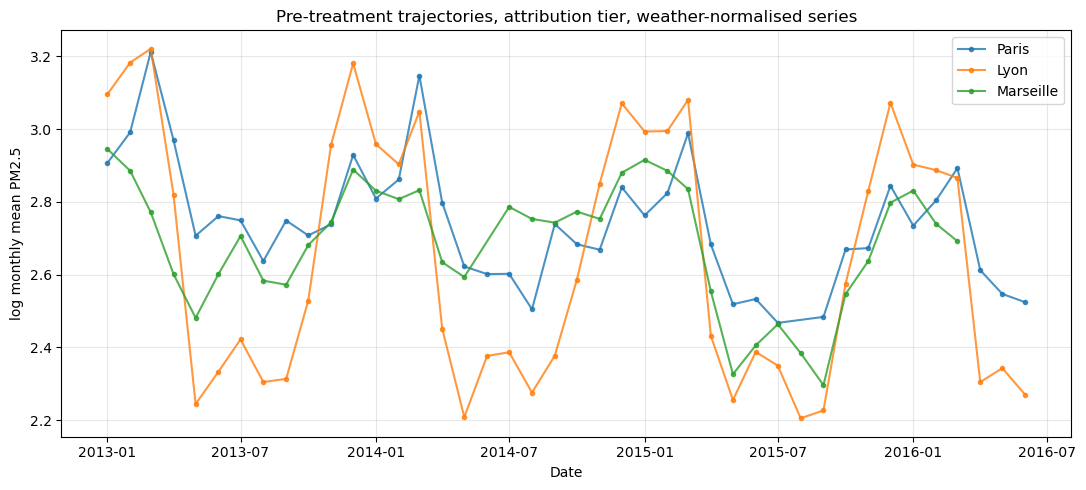

In [11]:
# Common monthly movement is deliberately left in these residuals. Removing it,
# as the estimation model does, would force the three cities' deviations to
# cancel and produce negative correlations by construction.
resid = pre.copy()
resid["_r"] = fit_panel(pre, "log_pm25 ~ 1 + t + EntityEffects").resids.values
city_res = (resid.groupby(["city", "date"], observed=True)["_r"].mean()
            .unstack(0).dropna())

if city_res.shape[1] >= 2:
    corr = city_res.corr().round(3)
    log.table("residual_comovement", corr.reset_index())
    off = corr.where(~np.eye(len(corr), dtype=bool)).stack()
    log.note(f"Unexplained monthly movement is correlated across the cities, "
             f"{off.min():.2f} to {off.max():.2f}, weakest between the two "
             f"furthest apart. That is consistent with regional episodes reaching "
             f"all three together, which is what the comparison assumes; it is "
             f"supporting evidence rather than proof.")

fig, ax = plt.subplots(figsize=(11, 5))
for city in ["Paris", "Lyon", "Marseille"]:
    s = pre[pre["city"] == city].groupby("date")["log_pm25"].mean()
    ax.plot(s.index, s.values, ".-", label=city, alpha=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("log monthly mean PM2.5")
ax.set_title("Pre-treatment trajectories, attribution tier, "
             f"{'observed' if MODE == 'raw' else 'weather-normalised'} series")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## C6. Overall pre-treatment assessment

The slope category is the starting point. A failed joint leads test moves the interpretation one level toward caution. When the final category is `bounded reporting`, the regression coefficient may still be shown as a model output, but it is not presented as a stand-alone causal answer.


In [12]:
order = ["proceed", "proceed with bias band", "bounded reporting"]
escalate = bool(np.isfinite(leads_p) and leads_p < ALPHA)
GATE_CATEGORY = order[min(order.index(category) + (1 if escalate else 0), 2)]

log.table("gate_outcome", pd.DataFrame([{
    "slope_gap_category": category,
    "slope_gap_m": round(m, 3),
    "leads_p": round(leads_p, 4) if np.isfinite(leads_p) else np.nan,
    "leads_escalates": escalate,
    "final_category": GATE_CATEGORY,
    "reporting_mode": {
        "proceed": "point estimate with interval",
        "proceed with bias band": "bias-band interpretation required",
        "bounded reporting": "range consistent with the data, with the smallest "
                             "detectable effect"}[GATE_CATEGORY]}]))

log.gate("combined pre-trend gates", GATE_CATEGORY != "bounded reporting",
         f"slope gap gives '{category}', leads "
         f"{'escalate' if escalate else 'do not escalate'}, "
         f"reporting mode: {GATE_CATEGORY}")



=== gate_outcome ===
slope_gap_category  slope_gap_m  leads_p  leads_escalates    final_category                                                      reporting_mode
 bounded reporting         5.83   0.0491             True bounded reporting range consistent with the data, with the smallest detectable effect
[gate] combined pre-trend gates: FAIL - slope gap gives 'bounded reporting', leads escalate, reporting mode: bounded reporting


## D1. Main panel estimate

The model compares the change in Paris after July 2017 with changes in Lyon and Marseille up to August 2022. Station effects absorb persistent differences between monitoring sites and common month effects absorb shocks shared by the cities. The earlier Paris measure is kept in its own segment.

Station-months are unweighted, so cities with more available stations contribute more observations. Equal city-month weighting is examined in S2.

The coefficient represents the Paris traffic-policy package over this period, not the vehicle restriction in isolation. Other changes to roads, parking, cycling and speeds occurred at similar times. Its interpretation also follows the pre-treatment assessment above.


In [13]:
primary = panel[(panel["tier"] == "attribution")
                & (panel["date"] >= PRIMARY_SAMPLE[0])
                & (panel["date"] <= PRIMARY_SAMPLE[1])].copy()

PRIMARY_FORMULA = ("log_pm25 ~ 1 + paris_post + paris_precursor "
                   "+ EntityEffects + TimeEffects")

prim_base, prim_draws = block_bootstrap(primary, PRIMARY_FORMULA, "paris_post")
log_fallbacks("Primary estimate")

primary_row = summarise(prim_base, prim_draws, "paris_post",
                        "Primary A: Paris after July 2017, against comparators")
primary_row["blocks_calendar_years"] = primary["year"].nunique()
primary_row["station_months"] = len(primary)
primary_row["stations"] = primary["station"].nunique()
PRIMARY_A = primary_row
log.table("primary_A", pd.DataFrame([primary_row]))

if GATE_CATEGORY == "bounded reporting":
    log.note("The pre-treatment assessment is bounded. This coefficient is "
             "shown as a model output, not as a stand-alone causal answer.")

prec = prim_base.params["paris_precursor"]
log.note(f"Precursor segment (mid-2016 to mid-2017) held separately: "
         f"{pct(prec):+.2f} percent, standard error "
         f"{prim_base.std_errors['paris_precursor']:.4f}. It is not part of the "
         f"main estimate and is reported so the period is visibly accounted for "
         f"rather than absorbed into either side of the comparison.")


[note] Primary estimate bootstrap: 74.8% same-month donor, 6.5% same-station donor-year fallback, 18.7% station-pool fallback; residual scale 1.1503; 2000 of 2000 fits used.

=== primary_A ===
                                             quantity  estimate_pct  ci_lo_pct  ci_hi_pct  excludes_zero  analytic_se_log  bootstrap_se_log  usable_draws  blocks_calendar_years  station_months  stations
Primary A: Paris after July 2017, against comparators        13.661      5.483     23.281           True          0.05339           0.03984          2000                     10             516         9
[note] The pre-treatment assessment is bounded. This coefficient is shown as a model output, not as a stand-alone causal answer.
[note] Precursor segment (mid-2016 to mid-2017) held separately: +0.13 percent, standard error 0.0491. It is not part of the main estimate and is reported so the period is visibly accounted for rather than absorbed into either side of the comparison.


### D2. Analytic inference comparison

The main interval is obtained from the year-block bootstrap. A Driscoll-Kraay interval with a Bartlett kernel and an 18-month bandwidth is reported as a comparison.

The methods need not agree. The bootstrap keeps dependence within calendar years but breaks it across year boundaries, whereas the kernel estimator allows dependence across those boundaries. Any conclusion-changing difference is reported directly.


In [14]:
b = prim_base.params["paris_post"]
se = prim_base.std_errors["paris_post"]
analytic = {"method": "analytic, correlation-corrected",
            "estimate_pct": round(pct(b), 3),
            "ci_lo_pct": round(pct(b - 1.96 * se), 3),
            "ci_hi_pct": round(pct(b + 1.96 * se), 3),
            "excludes_zero": bool(prim_base.pvalues["paris_post"] < ALPHA),
            "p_value": round(prim_base.pvalues["paris_post"], 4)}
boot = {"method": "resampled (governs)",
        "estimate_pct": PRIMARY_A["estimate_pct"],
        "ci_lo_pct": PRIMARY_A["ci_lo_pct"],
        "ci_hi_pct": PRIMARY_A["ci_hi_pct"],
        "excludes_zero": PRIMARY_A["excludes_zero"],
        "p_value": np.nan}

compare = pd.DataFrame([boot, analytic])
log.table("primary_A_inference_comparison", compare)

if boot["excludes_zero"] != analytic["excludes_zero"]:
    log.note("The two inference methods disagree about whether the effect is "
             "distinguishable from zero. The resampled interval governs, and the "
             "disagreement is reported rather than resolved.")
else:
    log.note("Both inference methods agree on whether the effect is "
             "distinguishable from zero.")



=== primary_A_inference_comparison ===
                         method  estimate_pct  ci_lo_pct  ci_hi_pct  excludes_zero  p_value
            resampled (governs)        13.661      5.483     23.281           True      NaN
analytic, correlation-corrected        13.661      2.369     26.198           True   0.0169
[note] Both inference methods agree on whether the effect is distinguishable from zero.


### D3. Half-year pattern

The half-year coefficients show when the Paris-comparator difference appears rather than averaging the whole post-2017 period into one number.

Later values require care because the Paris background record changes stations in 2019 with no overlap. Separate station effects absorb their average level difference, but they cannot identify a citywide change occurring at the handover.


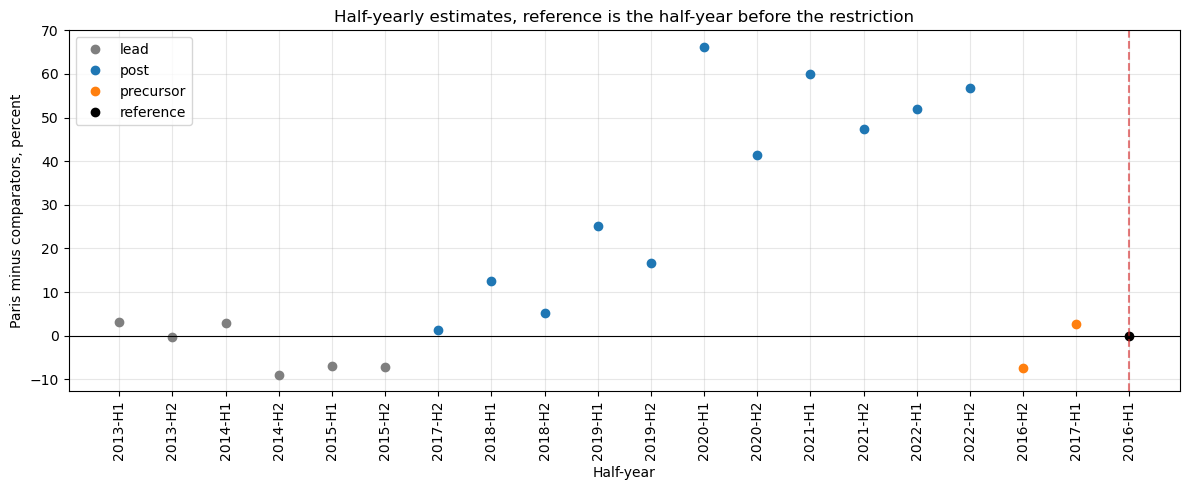

[note] Half-yearly estimates: 6 before the restriction, 2 covering the earlier partial measure, 11 after. Mean after +35.00 percent, range +1.28 to +66.24.


In [15]:
ev_post = event_tbl[event_tbl["role"] == "post"].copy()
ev_lead = event_tbl[event_tbl["role"] == "lead"].copy()

fig, ax = plt.subplots(figsize=(12, 5))
colours = {"lead": "tab:grey", "reference": "black",
           "precursor": "tab:orange", "post": "tab:blue"}
for role, grp in event_tbl.groupby("role"):
    ax.plot(grp["half_year"], grp["estimate_pct"], "o",
            color=colours[role], label=role)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(REFERENCE_HALF, color="tab:red", ls="--", alpha=0.6)
ax.set_xlabel("Half-year")
ax.set_ylabel("Paris minus comparators, percent")
ax.set_title("Half-yearly estimates, reference is the half-year before the restriction")
ax.tick_params(axis="x", rotation=90)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_prec = int((event_tbl["role"] == "precursor").sum())
log.note(f"Half-yearly estimates: {len(ev_lead)} before the restriction, "
         f"{n_prec} covering the earlier partial measure, {len(ev_post)} after. "
         f"Mean after {ev_post['estimate_pct'].mean():+.2f} percent, range "
         f"{ev_post['estimate_pct'].min():+.2f} to "
         f"{ev_post['estimate_pct'].max():+.2f}.")


### D4. Dose model

This secondary model replaces the binary Paris indicator with the prohibited fleet share and allows a separate coefficient for each city. It uses the full 2013-2025 window because the comparator restrictions enter through their own doses rather than contaminating an untreated control group.

Coefficients are reported per ten percentage-point increase in prohibited fleet share. The model assumes a linear and time-constant association and uses registered vehicles as a proxy for vehicles driven in the zone. It should therefore be read as supporting evidence, not as a separate causal identification strategy.


In [16]:
dose_sample = panel[
    (panel["tier"] == "attribution")
    & panel["date"].between(*map(pd.Timestamp, WINDOW_FULL))
].copy()

dose_sample["dose10"] = dose_sample["dose"] * 10
for city in ["Paris", "Lyon", "Marseille"]:
    dose_sample[f"dose_{city}"] = (
        dose_sample["dose10"] * (dose_sample["city"] == city).astype(int)
    )

dose_terms = ["dose_Paris", "dose_Lyon", "dose_Marseille"]
dose_formula = (
    "log_pm25 ~ 1 + " + " + ".join(dose_terms)
    + " + EntityEffects + TimeEffects"
)
dose_base, dose_draws = block_bootstrap(
    dose_sample, dose_formula, dose_terms
)
log_fallbacks("City-specific dose model")

rows = [
    summarise(
        dose_base, dose_draws, f"dose_{city}",
        f"{city}: effect per ten percentage points of prohibited fleet share",
    )
    for city in ["Paris", "Lyon", "Marseille"]
]

pooled_formula = "log_pm25 ~ 1 + dose10 + EntityEffects + TimeEffects"
pooled_base, pooled_draws = block_bootstrap(
    dose_sample, pooled_formula, "dose10"
)
rows.append(summarise(
    pooled_base, pooled_draws, "dose10",
    "Pooled: effect per ten percentage points of prohibited fleet share",
))

DOSE_RESULTS = pd.DataFrame(rows)
log.table("dose_secondary", DOSE_RESULTS)

span = (dose_sample.groupby("city", observed=True)["dose"]
        .agg(["min", "max", "mean"]).round(4).reset_index())
span.columns = ["city", "dose_min", "dose_max", "dose_mean"]
log.table("dose_variation_by_city", span)
log.note(
    "The city-specific coefficients allow different dose associations. The pooled "
    "coefficient imposes one common association and is shown only as a comparison."
)


[note] City-specific dose model bootstrap: 70.5% same-month donor, 3.3% same-station donor-year fallback, 26.3% station-pool fallback; residual scale 1.1215; 2000 of 2000 fits used.

=== dose_secondary ===
                                                             quantity  estimate_pct  ci_lo_pct  ci_hi_pct  excludes_zero  analytic_se_log  bootstrap_se_log  usable_draws
    Paris: effect per ten percentage points of prohibited fleet share         4.637     -1.810     11.782          False          0.03850           0.03293          2000
     Lyon: effect per ten percentage points of prohibited fleet share         6.349      2.512     11.308           True          0.03122           0.02132          2000
Marseille: effect per ten percentage points of prohibited fleet share         8.347     -2.114     21.500          False          0.05062           0.05553          2000
   Pooled: effect per ten percentage points of prohibited fleet share         5.867      2.182     10.544         

### D5. Stability of the fitted weather models

The panel intervals condition on weather models that were estimated earlier. Fully propagating model-fitting uncertainty would require refitting every weather model inside every panel bootstrap draw.

Notebook 05 instead refitted the weather model 50 times for one long-record station per city and measured how much the fitted monthly weather component changed. That is a limited stability diagnostic, not uncertainty in the final policy coefficient, so it cannot simply be added to the confidence intervals below.


In [17]:
generated = pkg.get("generated_outcome")
required = {"station", "refits", "mean_monthly_sd", "as_pct_of_level"}

if isinstance(generated, pd.DataFrame) and required.issubset(generated.columns):
    generated = generated.copy()
    log.table("weather_model_fit_sensitivity", generated)
    log.note(
        f"Across the selected stations, the average monthly fitted-component "
        f"variation is {generated['as_pct_of_level'].min():.2f}% to "
        f"{generated['as_pct_of_level'].max():.2f}% of the station level. "
        "This is a model-stability diagnostic, not an adjustment to the panel interval."
    )
else:
    log.note(
        "The weather-model refit diagnostic is not available in the validation "
        "package. Re-run notebook 05 to create it."
    )



=== weather_model_fit_sensitivity ===
station  refits  mean_monthly_sd  as_pct_of_level  seconds
FR04143      50           0.1208            0.808      300
FR20062      50           0.1100            0.840      704
FR03043      50           0.0965            0.838      664
[note] Across the selected stations, the average monthly fitted-component variation is 0.81% to 0.84% of the station level. This is a model-stability diagnostic, not an adjustment to the panel interval.


## E. Sensitivity analyses

These variations check whether the main coefficient depends heavily on one station, weighting rule or period. Some are re-estimated with bootstrap intervals; the others are point-estimate comparisons.

S8 and S9 answer slightly different questions. S8 tests sensitivity to the normalisation's time features. S9 documents the available surrounding-area series, which is used descriptively because the communes do not share one verified legal onset.


In [18]:
SENS_FORMULA = PRIMARY_FORMULA
sens_rows = []


def sens_point(df, label, note="", with_ci=False, formula=SENS_FORMULA,
               coef="paris_post", weight_col=None):
    """Re-estimate a variant and record its change from the main model."""
    try:
        if with_ci:
            fitted, draws = block_bootstrap(
                df, formula, coef, weight_col=weight_col
            )
            estimate = pct(fitted.params[coef])
            lower, upper = np.percentile(draws[coef], [2.5, 97.5])
            lower, upper = pct(lower), pct(upper)
        else:
            fitted = fit_panel(df, formula, weight_col=weight_col)
            estimate = pct(fitted.params[coef])
            lower = upper = np.nan

        sens_rows.append({
            "sensitivity": label,
            "estimate_pct": round(estimate, 3),
            "ci_lo_pct": round(lower, 3) if np.isfinite(lower) else np.nan,
            "ci_hi_pct": round(upper, 3) if np.isfinite(upper) else np.nan,
            "shift_from_headline": round(
                estimate - PRIMARY_A["estimate_pct"], 3
            ),
            "station_months": len(df),
            "stations": df["station"].nunique(),
            "note": note,
        })
    except Exception as exc:
        sens_rows.append({
            "sensitivity": label,
            "estimate_pct": np.nan,
            "ci_lo_pct": np.nan,
            "ci_hi_pct": np.nan,
            "shift_from_headline": np.nan,
            "station_months": len(df),
            "stations": df["station"].nunique(),
            "note": f"not estimable: {exc}",
        })


base_sample = panel[
    (panel["tier"] == "attribution")
    & panel["date"].between(*map(pd.Timestamp, PRIMARY_SAMPLE))
].copy()


### S1. Remove the station outside Lyon commune

FR20046 is an urban-background station in the continuous Lyon built-up area but outside the Lyon commune and outside the restricted perimeter. This variation removes it. It also removes the station with the 2024 record gap.


In [19]:
sens_point(base_sample[base_sample["station"] != "FR20046"],
           "S1 commune-boundary variant, Lyon station outside the city removed",
           note="also serves as the check on that station's 2024 record gap",
           with_ci=True)


### S2. Equal city-month weighting

The main model gives each station-month equal weight. Here, each observation receives weight equal to one divided by the number of stations available for its city and month. Each represented city therefore contributes the same total weight in that month. Months with no eligible Paris observation cannot be repaired by weighting, so the missing 2019 months are listed explicitly.


In [20]:
w = base_sample.copy()
stations_in_city_month = (
    w.groupby(["city", "ym"], observed=True)["station"].transform("nunique")
)
w["weight"] = 1.0 / stations_in_city_month

present_2019 = sorted(
    w.loc[(w["city"] == "Paris") & (w["year"] == 2019),
          "month_of_year"].unique()
)
missing_2019 = [month for month in range(1, 13) if month not in present_2019]
log.note(
    f"Equal city-month weighting: Paris contributes {len(present_2019)} of 12 "
    f"months in 2019. Missing month numbers: {missing_2019}."
)

sens_point(
    w,
    "S2 equal city-month weighting",
    note="each represented city receives equal total weight in each month",
    with_ci=True,
    weight_col="weight",
)


[note] Equal city-month weighting: Paris contributes 8 of 12 months in 2019. Missing month numbers: [2, 9, 10, 11].


### S3. Longest-record stations

This variation retains the designated long-record stations. Paris still requires two separate station identifiers around the 2019 handover, while Lyon and Marseille each contribute one station. The specification is otherwise unchanged.


In [21]:
anchor_set = [s for v in ANCHORS_ATTRIB.values() for s in v]
sens_point(base_sample[base_sample["station"].isin(anchor_set)],
           "S3 longest-record stations only",
           note=f"{', '.join(anchor_set)}; Paris pair kept separate, "
                f"each with its own fixed effect",
           with_ci=True)


### S4. Earlier period

This version re-estimates the model through the end of 2019 and describes 2020 onward separately. It removes the pandemic and later policy years, although it still contains the December 2019 observation from the replacement Paris station and therefore does not eliminate the handover completely.


In [22]:
sens_point(base_sample[base_sample["date"] <= "2019-12-31"],
           "S4 earlier era only, to end 2019",
           note="December 2019 still uses the replacement Paris station; "
                "the pandemic and later years are removed",
           with_ci=True)

later = panel[(panel["tier"] == "attribution")
              & (panel["date"] >= "2020-01-01")
              & (panel["date"] <= PRIMARY_SAMPLE[1])]
later_desc = (later.groupby("city", observed=True)["pm25"]
              .agg(["count", "mean"]).round(3).reset_index())
later_desc.columns = ["city", "station_months", "mean_pm25"]
log.table("S4_later_era_descriptive", later_desc)



=== S4_later_era_descriptive ===
     city  station_months  mean_pm25
    Paris              45     11.645
     Lyon              87     11.015
Marseille              64     10.333


### S5. Excluding the main pandemic period

March 2020 to June 2021 is removed because traffic changed sharply and may not have changed in the same way across all three cities. Common month effects absorb shared shocks, but not city-specific responses.


In [23]:
covid = ((base_sample["date"] >= "2020-03-01")
         & (base_sample["date"] <= "2021-06-30"))
sens_point(base_sample[~covid], "S5 pandemic months excluded",
           note="March 2020 to June 2021 dropped", with_ci=True)


### S6 and S7. Olympics and final-year checks

The summer 2024 Olympics and the 2025 restriction changes lie outside the main sample, so these checks use the full 2013-2025 window. S6 holds the Paris Olympic months in a separate indicator. S7 compares the full window with a version ending in 2024.


In [24]:
full = panel[panel["tier"] == "attribution"].copy()
full["paris_olympics"] = ((full["city"] == "Paris")
                          & (full["date"] >= "2024-07-01")
                          & (full["date"] <= "2024-09-30")).astype(int)

f_with = fit_panel(full,
                   "log_pm25 ~ 1 + paris_post + paris_precursor + paris_olympics "
                   "+ EntityEffects + TimeEffects")
f_without = fit_panel(full[full["paris_olympics"] == 0], SENS_FORMULA)

sens_rows.append({
    "sensitivity": "S6 Olympics period, full window",
    "estimate_pct": round(pct(f_with.params["paris_post"]), 3),
    "ci_lo_pct": np.nan, "ci_hi_pct": np.nan,
    "shift_from_headline": np.nan,
    "station_months": len(full), "stations": full["station"].nunique(),
    "note": f"summer 2024 held separately, its own coefficient "
            f"{pct(f_with.params['paris_olympics']):+.2f} percent; excluding "
            f"those months instead gives "
            f"{pct(f_without.params['paris_post']):+.2f} percent"})

no25 = full[full["date"] <= "2024-12-31"]
sens_rows.append({
    "sensitivity": "S7 final year excluded, full window",
    "estimate_pct": round(pct(fit_panel(no25, SENS_FORMULA).params["paris_post"]), 3),
    "ci_lo_pct": np.nan, "ci_hi_pct": np.nan,
    "shift_from_headline": np.nan,
    "station_months": len(no25), "stations": no25["station"].nunique(),
    "note": "2025 carries a further restriction step and provisional fleet data; "
            f"including it gives "
            f"{pct(fit_panel(full, SENS_FORMULA).params['paris_post']):+.2f} percent"})


### S8. Weather-only normalisation

The main random-forest model includes time features as well as meteorology. The alternative series from notebook 05 removes all time features and uses meteorological inputs only.

This changes more than the date trend alone: it also removes seasonal and hourly time variables, while meteorological variables may still carry some seasonality. The difference from the main estimate is therefore a broad sensitivity check, not a formal bound on leakage.


In [25]:
missing_weather_only = [
    station for station in STATIONS
    if not os.path.exists(
        f"data/interim/norm_weatheronly_unclipped_{station}.pkl"
    )
]

if not missing_weather_only:
    s8_panel = load_panel("weather_only")
    s8 = s8_panel[
        (s8_panel["tier"] == "attribution")
        & s8_panel["date"].between(*map(pd.Timestamp, PRIMARY_SAMPLE))
    ]
    sens_point(
        s8,
        "S8 meteorology-only normalisation",
        note="all time features removed; broad sensitivity rather than a leakage bound",
        with_ci=True,
    )
    s8_estimate = sens_rows[-1]["estimate_pct"]
    if np.isfinite(s8_estimate):
        log.note(
            f"Meteorology-only estimate {s8_estimate:+.2f}% versus main-model "
            f"estimate {PRIMARY_A['estimate_pct']:+.2f}%; difference "
            f"{s8_estimate - PRIMARY_A['estimate_pct']:+.2f} percentage points."
        )
else:
    sens_rows.append({
        "sensitivity": "S8 meteorology-only normalisation",
        "estimate_pct": np.nan,
        "ci_lo_pct": np.nan,
        "ci_hi_pct": np.nan,
        "shift_from_headline": np.nan,
        "station_months": 0,
        "stations": 0,
        "note": "missing weather-only files: " + ", ".join(missing_weather_only),
    })


[note] Meteorology-only estimate +9.52% versus main-model estimate +13.66%; difference -4.14 percentage points.


### S9. Surrounding Paris area

The main estimate uses stations inside Paris proper. Notebook 05 also creates a panel of available background stations in surrounding communes. That panel is useful for comparing the shape of the series, but it cannot be assigned the Paris-proper onset.

The metropolitan scheme began in July 2019, but implementation originally depended on local mayoral orders and adoption varied across communes. A single treatment indicator would therefore misclassify at least part of this panel. This section checks its coverage and P2 later compares its relative path with Paris proper. It does not estimate a scalar treatment effect.


In [26]:
s9_path = "data/interim/panel_zonewide.pkl"

if os.path.exists(s9_path):
    zone = pd.read_pickle(s9_path)
    value_column = "pm25_observed" if MODE == "raw" else "pm25"
    required = {"station", "city", "ym", value_column}
    missing = required - set(zone.columns)
    if missing:
        raise ValueError(f"surrounding-area panel is missing {sorted(missing)}")

    z = zone.copy()
    z["analysis_pm25"] = z[value_column]
    if z["analysis_pm25"].isna().any() or (z["analysis_pm25"] <= 0).any():
        raise ValueError("surrounding-area PM2.5 must be positive and complete")

    coverage = (
        z.groupby("station")
        .agg(
            first_month=("ym", "min"),
            last_month=("ym", "max"),
            station_months=("ym", "nunique"),
            mean_pm25=("analysis_pm25", "mean"),
        )
        .reset_index()
    )
    coverage["mean_pm25"] = coverage["mean_pm25"].round(3)
    log.table("surrounding_area_coverage", coverage)

    sens_rows.append({
        "sensitivity": "S9 surrounding-area comparison",
        "estimate_pct": np.nan,
        "ci_lo_pct": np.nan,
        "ci_hi_pct": np.nan,
        "shift_from_headline": np.nan,
        "station_months": len(z),
        "stations": z["station"].nunique(),
        "note": "descriptive path reported in P2; no common verified legal onset",
    })
else:
    sens_rows.append({
        "sensitivity": "S9 surrounding-area comparison",
        "estimate_pct": np.nan,
        "ci_lo_pct": np.nan,
        "ci_hi_pct": np.nan,
        "shift_from_headline": np.nan,
        "station_months": 0,
        "stations": 0,
        "note": "the surrounding-area panel has not been built",
    })

log.note(
    "No scalar treatment coefficient is estimated for the surrounding-area "
    "panel because the included communes do not share one verified onset."
)



=== surrounding_area_coverage ===
station first_month last_month  station_months  mean_pm25
FR04002     2013-01    2025-12             139     11.906
FR04034     2013-01    2025-12             153     11.603
FR04150     2021-02    2025-12              37      9.767
FR04156     2013-01    2025-12             155     11.431
[note] No scalar treatment coefficient is estimated for the surrounding-area panel because the included communes do not share one verified onset.


### Comparing the sensitivity estimates

The table reports the change from the main model estimate where that comparison is meaningful. The full-window checks and weather-only series should also be read using their notes because they change more than one feature of the main estimand. S9 has no scalar estimate because it is used only as a descriptive path comparison.


In [27]:
SENSITIVITIES = pd.DataFrame(sens_rows)
log.table("sensitivities", SENSITIVITIES)

computed = SENSITIVITIES.dropna(subset=["shift_from_headline"])
if len(computed):
    worst = computed.loc[computed["shift_from_headline"].abs().idxmax()]
    log.note(f"Across the {len(computed)} variants with a comparable estimate, "
             f"the main-model estimate of {PRIMARY_A['estimate_pct']:+.2f} percent moves at "
             f"most {worst['shift_from_headline']:+.2f} points, under "
             f"'{worst['sensitivity']}'. Unavailable variants are "
             f"listed with the reason.")



=== sensitivities ===
                                                       sensitivity  estimate_pct  ci_lo_pct  ci_hi_pct  shift_from_headline  station_months  stations                                                                                                                note
S1 commune-boundary variant, Lyon station outside the city removed        13.449      3.673     24.037               -0.212             407         8                                                          also serves as the check on that station's 2024 record gap
                                     S2 equal city-month weighting        13.740      5.346     22.817                0.079             516         9                                                     each represented city receives equal total weight in each month
                                   S3 longest-record stations only        13.449      2.755     24.693               -0.212             332         4                        FR0414

## F1. False-onset checks

These tests ask whether the estimator also produces large coefficients when the Paris start date is moved to January 2014, 2015 or 2016. The real July 2016-June 2017 precursor remains a separate control in those regressions.

A second executable check compares Lyon with Marseille at an invented January 2018 onset while neither city is treated. A shared September 2022 onset cannot provide an untreated comparison because both cities begin their restrictions together; it is recorded as not used rather than counted as a successful placebo.

Each usable coefficient is divided by its bootstrap standard error and compared with the corresponding ratio from the main model. This family is a diagnostic rather than a multiple-testing exercise.


In [28]:
def t_ratio(df, formula, coef):
    """Coefficient divided by its bootstrap standard error."""
    fitted, draws = block_bootstrap(df, formula, coef)
    bootstrap_se = float(draws[coef].std(ddof=1))
    ratio = abs(fitted.params[coef]) / bootstrap_se if bootstrap_se > 0 else np.nan
    return fitted.params[coef], bootstrap_se, ratio


b_main, se_main, t_main = t_ratio(primary, PRIMARY_FORMULA, "paris_post")
log.note(
    f"Main-model comparison ratio: {b_main:+.4f} / {se_main:.4f} = {t_main:.2f}."
)

placebo_rows = []
for fake_onset in ["2014-01-01", "2015-01-01", "2016-01-01"]:
    false_sample = base_sample[base_sample["date"] < PARIS_CORE["step1"]].copy()
    false_sample["false_post"] = (
        (false_sample["city"] == "Paris")
        & (false_sample["date"] >= fake_onset)
    ).astype(int)

    formula = (
        "log_pm25 ~ 1 + false_post + paris_precursor "
        "+ EntityEffects + TimeEffects"
    )
    coefficient, bootstrap_se, ratio = t_ratio(
        false_sample, formula, "false_post"
    )
    placebo_rows.append({
        "placebo": f"Paris start moved to {fake_onset[:7]}",
        "coefficient": round(coefficient, 4),
        "resampled_se": round(bootstrap_se, 4),
        "ratio": round(ratio, 3),
        "as_large_as_headline": bool(ratio >= t_main),
        "sample": "before July 2017; precursor controlled separately",
        "station_months": len(false_sample),
    })

placebo_rows.append({
    "placebo": "Shared Lyon-Marseille onset, 2022-09 (not used)",
    "coefficient": np.nan,
    "resampled_se": np.nan,
    "ratio": np.nan,
    "as_large_as_headline": np.nan,
    "sample": "both cities treated together, so there is no untreated comparison",
    "station_months": 0,
})

FALSE_COMPARATOR_ONSET = "2018-01-01"
comp = panel[
    (panel["tier"] == "attribution")
    & (panel["city"] != "Paris")
    & panel["date"].between(*map(pd.Timestamp, PRIMARY_SAMPLE))
].copy()
comp["lyon_post"] = (
    (comp["city"] == "Lyon")
    & (comp["date"] >= FALSE_COMPARATOR_ONSET)
).astype(int)
coefficient, bootstrap_se, ratio = t_ratio(
    comp,
    "log_pm25 ~ 1 + lyon_post + EntityEffects + TimeEffects",
    "lyon_post",
)
placebo_rows.append({
    "placebo": "Lyon versus Marseille, invented start 2018-01",
    "coefficient": round(coefficient, 4),
    "resampled_se": round(bootstrap_se, 4),
    "ratio": round(ratio, 3),
    "as_large_as_headline": bool(ratio >= t_main),
    "sample": "comparator cities through August 2022; neither treated",
    "station_months": len(comp),
})

PLACEBOS = pd.DataFrame(placebo_rows)
log.table("placebo_family", PLACEBOS)

executable = PLACEBOS.dropna(subset=["ratio"])
PLACEBO_BREACH = bool(executable["as_large_as_headline"].any())
log.gate(
    "false-onset checks",
    not PLACEBO_BREACH,
    f"largest usable ratio {executable['ratio'].max():.2f} versus "
    f"main-model ratio {t_main:.2f}",
)


[note] Main-model comparison ratio: +0.1280 / 0.0398 = 3.21.

=== placebo_family ===
                                        placebo  coefficient  resampled_se  ratio as_large_as_headline                                                            sample  station_months
                   Paris start moved to 2014-01      -0.0564        0.0438  1.288                False                 before July 2017; precursor controlled separately             207
                   Paris start moved to 2015-01      -0.0400        0.0396  1.010                False                 before July 2017; precursor controlled separately             207
                   Paris start moved to 2016-01       0.0263        0.0629  0.418                False                 before July 2017; precursor controlled separately             207
Shared Lyon-Marseille onset, 2022-09 (not used)          NaN           NaN    NaN                  NaN both cities treated together, so there is no untreated comparison       

## F2. Roadside increment

For Paris and Marseille, the increment is the roadside log concentration minus the mean log concentration at that city's background stations in the same month. It approximates how much higher pollution is beside the road than in the wider urban background.

This is supporting evidence only. Each city has one roadside site and the calculation inherits limitations in the background series.


In [29]:
def increment(city, traffic_station):
    """Monthly log difference between the roadside station and the city background."""
    t = (panel[panel["station"] == traffic_station]
         .set_index("ym")["log_pm25"].rename("traffic"))
    b = (panel[(panel["city"] == city) & (panel["tier"] == "attribution")]
         .groupby("ym")["log_pm25"].mean().rename("background"))
    d = pd.concat([t, b], axis=1).dropna()
    out = (d["traffic"] - d["background"]).rename("increment").reset_index()
    out["date"] = out["ym"].dt.to_timestamp()
    out["city"] = city
    out["station"] = city
    out["month_of_year"] = out["date"].dt.month
    out["year"] = out["date"].dt.year
    return out

inc = pd.concat([increment("Paris", "FR04329"),
                 increment("Marseille", "FR03006")], ignore_index=True)

desc = (inc.groupby("city", observed=True)["increment"]
        .agg(["count", "mean", "std"]).round(4).reset_index())
desc.columns = ["city", "months", "mean_log_increment", "sd"]
log.table("roadside_increment_summary", desc)



=== roadside_increment_summary ===
     city  months  mean_log_increment     sd
Marseille     139              0.1878 0.0911
    Paris     148              0.2164 0.1040


### F3. Comparing Paris and Marseille increments

The primary step model uses all available history from January 2013. The observations in January-June 2019 remain in the sample, while one Paris interaction begins in July 2019 and a second begins in June 2021, following the ring-road restriction dates. Station and month effects are included, and uncertainty is estimated with the year-block bootstrap.

The July 2019 coefficient is difficult to separate from the Paris background-station handover and is not treated as the main mechanism result. The June 2021 coefficient is cleaner but still not unconfounded: other citywide traffic measures can affect the background part of the increment.

The primary mechanism window ends in August 2022. From September 2022 Marseille's own restriction covers its background area while the roadside comparison site is outside the zone, which can change the Marseille increment. A full-window result is shown separately with this limitation. A January 2019 start is also retained as a near-event sensitivity, but its short pre-period cannot replace the full-history estimate. The half-year display uses 2019-H1 as the omitted reference and tests the earlier coefficients jointly. If that test rejects, the mechanism results are treated as supporting evidence rather than causal estimates.



=== increment_did ===
                           quantity  estimate_pct  ci_lo_pct  ci_hi_pct  excludes_zero  analytic_se_log  bootstrap_se_log  usable_draws                                                               window                    construction  months  station_months
           July 2019 ring-road step        10.259     -6.852     28.779          False          0.06648           0.08279          2000                                          January 2013 to August 2022            full-history primary     116             207
June 2021 additional ring-road step         3.115    -17.623     22.397          False          0.04916           0.10061          2000                                          January 2013 to August 2022            full-history primary     116             207
           July 2019 ring-road step        10.259     -5.812     28.023          False          0.06491           0.07912          2000 January 2013 to December 2025 (Marseille confound after Au

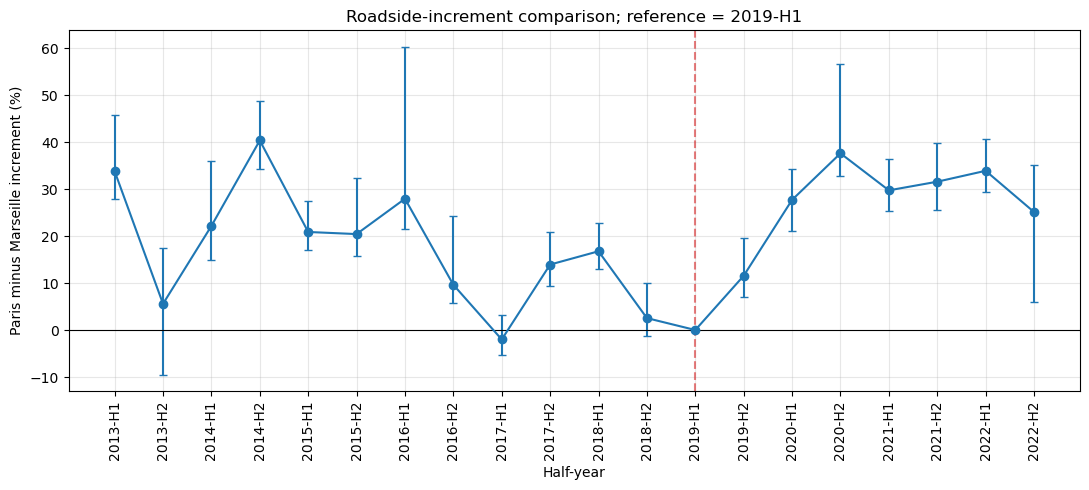

[note] The primary mechanism window ends before Marseille's restriction. The full-window coefficients may be affected by Marseille's treated background area. The joint lead test governs interpretation: rejection means that the mechanism coefficients remain supporting rather than causal, even if an interval excludes zero.


In [30]:
def fit_increment_steps(sample, label, construction, start_date=None):
    """Estimate the two Paris-relative roadside-increment steps."""
    data = sample.copy()
    if start_date is not None:
        data = data[data["date"] >= start_date].copy()
    is_paris = (data["city"] == "Paris").astype(int)
    data["paris_2019"] = is_paris * (
        data["date"] >= PERIPHERIQUE["step1"]
    ).astype(int)
    data["paris_2021"] = is_paris * (
        data["date"] >= PERIPHERIQUE["step2"]
    ).astype(int)

    formula = (
        "increment ~ 1 + paris_2019 + paris_2021 "
        "+ EntityEffects + TimeEffects"
    )
    fitted, draws = block_bootstrap(
        data, formula, ["paris_2019", "paris_2021"]
    )
    rows = []
    for term, event in [
        ("paris_2019", "July 2019 ring-road step"),
        ("paris_2021", "June 2021 additional ring-road step"),
    ]:
        row = summarise(fitted, draws, term, event)
        row.update({
            "window": label,
            "construction": construction,
            "months": data["ym"].nunique(),
            "station_months": len(data),
        })
        rows.append(row)
    return rows


primary_increment = inc[inc["date"] <= "2022-08-31"].copy()
increment_rows = fit_increment_steps(
    primary_increment,
    "January 2013 to August 2022",
    "full-history primary",
)
increment_rows += fit_increment_steps(
    inc,
    "January 2013 to December 2025 (Marseille confound after August 2022)",
    "full-history, extended endpoint",
)
increment_rows += fit_increment_steps(
    primary_increment,
    "January 2019 to August 2022",
    "near-event sensitivity",
    start_date="2019-01-01",
)
INCREMENT_DID = pd.DataFrame(increment_rows)
log.table("increment_did", INCREMENT_DID)

# Half-year leads relative to 2019-H1.
lead_data = primary_increment.copy()
lead_data["half"] = (
    lead_data["date"].dt.year.astype(str)
    + np.where(lead_data["date"].dt.month <= 6, "-H1", "-H2")
)
lead_data["is_paris"] = (lead_data["city"] == "Paris").astype(int)
mechanism_reference = "2019-H1"
mechanism_halves = sorted(lead_data["half"].unique())
mechanism_terms = []
for half_year in mechanism_halves:
    if half_year == mechanism_reference:
        continue
    term = "m_" + half_year.replace("-", "_")
    lead_data[term] = (
        lead_data["is_paris"] * (lead_data["half"] == half_year).astype(int)
    )
    mechanism_terms.append(term)

mechanism_formula = (
    "increment ~ 1 + " + " + ".join(mechanism_terms)
    + " + EntityEffects + TimeEffects"
)
mechanism_fit, mechanism_draws = block_bootstrap(
    lead_data, mechanism_formula, mechanism_terms
)
mechanism_event = pd.DataFrame([
    {
        "half_year": half_year,
        "estimate_pct": (0.0 if half_year == mechanism_reference else
                         round(pct(mechanism_fit.params[
                             "m_" + half_year.replace("-", "_")
                         ]), 3)),
        "ci_lo_pct": (0.0 if half_year == mechanism_reference else
                      round(pct(np.percentile(
                          mechanism_draws[
                              "m_" + half_year.replace("-", "_")
                          ], 2.5
                      )), 3)),
        "ci_hi_pct": (0.0 if half_year == mechanism_reference else
                      round(pct(np.percentile(
                          mechanism_draws[
                              "m_" + half_year.replace("-", "_")
                          ], 97.5
                      )), 3)),
        "role": ("reference" if half_year == mechanism_reference else
                 "lead" if half_year < mechanism_reference else "post"),
    }
    for half_year in mechanism_halves
])
log.table("roadside_increment_half_years", mechanism_event)

mechanism_leads = [
    "m_" + half_year.replace("-", "_")
    for half_year in mechanism_halves if half_year < mechanism_reference
]
lead_vector = mechanism_fit.params[mechanism_leads].to_numpy()
lead_covariance = np.cov(
    mechanism_draws[mechanism_leads].to_numpy(), rowvar=False
)
lead_stat = float(
    lead_vector @ np.linalg.pinv(np.atleast_2d(lead_covariance)) @ lead_vector
)
mechanism_leads_p = float(stats.chi2.sf(lead_stat, df=len(mechanism_leads)))
log.table("roadside_increment_leads_test", pd.DataFrame([{
    "terms_tested": len(mechanism_leads),
    "chi2_bootstrap": round(lead_stat, 3),
    "p_bootstrap": round(mechanism_leads_p, 4),
}]))

fig, ax = plt.subplots(figsize=(11, 5))
ax.errorbar(
    mechanism_event["half_year"],
    mechanism_event["estimate_pct"],
    yerr=[
        np.maximum(
            mechanism_event["estimate_pct"] - mechanism_event["ci_lo_pct"], 0
        ),
        np.maximum(
            mechanism_event["ci_hi_pct"] - mechanism_event["estimate_pct"], 0
        ),
    ],
    fmt="o-", capsize=3,
)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(mechanism_reference, color="tab:red", ls="--", alpha=0.6)
ax.set_xlabel("Half-year")
ax.set_ylabel("Paris minus Marseille increment (%)")
ax.set_title("Roadside-increment comparison; reference = 2019-H1")
ax.tick_params(axis="x", rotation=90)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

log.note(
    "The primary mechanism window ends before Marseille's restriction. The "
    "full-window coefficients may be affected by Marseille's treated background "
    "area. The joint lead test governs interpretation: rejection means that the "
    "mechanism coefficients remain supporting rather than causal, even if an "
    "interval excludes zero."
)


### F4. Roadside-to-roadside comparison

This check compares the Paris and Marseille roadside stations directly, without subtracting background concentrations. It avoids the Paris background handover but is more exposed to city-specific weather and background pollution.

The primary construction uses all available months from January 2013, with the same July 2019 and June 2021 steps, calendar-month controls and year-block bootstrap intervals. The window ending in August 2022 is primary and the complete window is shown separately. Normalised and observed series are both reported. A January 2019 start is retained as a near-event sensitivity, and a half-year display checks the earlier path for the normalised series.



=== roadside_against_roadside ===
                           quantity  estimate_pct  ci_lo_pct  ci_hi_pct  excludes_zero  analytic_se_log  bootstrap_se_log  usable_draws     series                        window                    construction  months
           July 2019 ring-road step        15.526      2.730     31.441           True          0.03543           0.05884          2000 normalised   January 2013 to August 2022            full-history primary     102
June 2021 additional ring-road step        -3.839    -16.288     10.334          False          0.01279           0.06945          2000 normalised   January 2013 to August 2022            full-history primary     102
           July 2019 ring-road step        15.419      4.036     31.240           True          0.03505           0.05864          2000 normalised January 2013 to December 2025 full-history, extended endpoint     142
June 2021 additional ring-road step        -9.813    -20.508      0.859          False          0

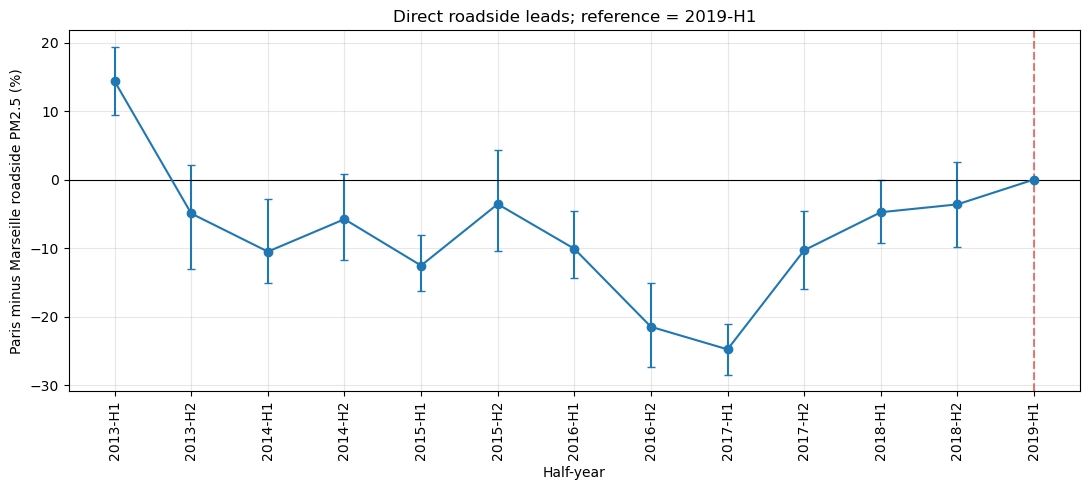

[note] Only one roadside station is available in each city, so site-specific changes cannot be separated from changes in traffic. The direct lead test must also be considered before interpreting the step estimates. A rejected lead test makes the coefficients supporting rather than causal.


In [31]:
def roadside_difference(source_panel):
    paris_road = (source_panel[source_panel["station"] == "FR04329"]
                  .set_index("ym")["log_pm25"].rename("paris"))
    marseille_road = (source_panel[source_panel["station"] == "FR03006"]
                      .set_index("ym")["log_pm25"].rename("marseille"))
    data = pd.concat([paris_road, marseille_road], axis=1).dropna()
    data["roadside_diff"] = data["paris"] - data["marseille"]
    data = data.reset_index()
    data["date"] = data["ym"].dt.to_timestamp()
    data["year"] = data["date"].dt.year
    data["month_of_year"] = data["date"].dt.month
    data["station"] = "roadside_difference"
    return data


def fit_roadside_steps(
    data, label, series, construction, start_date=None
):
    sample = data.copy()
    if start_date is not None:
        sample = sample[sample["date"] >= start_date].copy()
    sample["step_2019"] = (
        sample["date"] >= PERIPHERIQUE["step1"]
    ).astype(int)
    sample["step_2021"] = (
        sample["date"] >= PERIPHERIQUE["step2"]
    ).astype(int)
    formula = (
        "roadside_diff ~ 1 + step_2019 + step_2021 + C(month_of_year)"
    )
    fitted, draws = block_bootstrap(
        sample, formula, ["step_2019", "step_2021"]
    )
    rows = []
    for term, event in [
        ("step_2019", "July 2019 ring-road step"),
        ("step_2021", "June 2021 additional ring-road step"),
    ]:
        row = summarise(fitted, draws, term, event)
        row.update({"series": series, "window": label,
                    "construction": construction,
                    "months": len(sample)})
        rows.append(row)
    return rows


comparison_panels = {MODE: panel}
other_mode = "raw" if MODE == "normalised" else "normalised"
comparison_panels[other_mode] = load_panel(other_mode)

roadside_rows = []
for series, source_panel in comparison_panels.items():
    difference = roadside_difference(source_panel)
    roadside_rows += fit_roadside_steps(
        difference[difference["date"] <= "2022-08-31"],
        "January 2013 to August 2022",
        series,
        "full-history primary",
    )
    roadside_rows += fit_roadside_steps(
        difference,
        "January 2013 to December 2025",
        series,
        "full-history, extended endpoint",
    )
    roadside_rows += fit_roadside_steps(
        difference[difference["date"] <= "2022-08-31"],
        "January 2019 to August 2022",
        series,
        "near-event sensitivity",
        start_date="2019-01-01",
    )

M2 = pd.DataFrame(roadside_rows)
log.table("roadside_against_roadside", M2)

# Half-year lead diagnostic for the normalised roadside difference.
roadside_lead_data = roadside_difference(
    comparison_panels["normalised"]
)
roadside_lead_data = roadside_lead_data[
    roadside_lead_data["date"] <= "2022-08-31"
].copy()
roadside_lead_data["half"] = (
    roadside_lead_data["date"].dt.year.astype(str)
    + np.where(
        roadside_lead_data["date"].dt.month <= 6, "-H1", "-H2"
    )
)
roadside_reference = "2019-H1"
roadside_lead_halves = sorted(
    half_year for half_year in roadside_lead_data["half"].unique()
    if half_year < roadside_reference
)
roadside_terms = []
for half_year in roadside_lead_halves:
    term = "r_" + half_year.replace("-", "_")
    roadside_lead_data[term] = (
        roadside_lead_data["half"] == half_year
    ).astype(int)
    roadside_terms.append(term)

roadside_lead_data["step_2019"] = (
    roadside_lead_data["date"] >= PERIPHERIQUE["step1"]
).astype(int)
roadside_lead_data["step_2021"] = (
    roadside_lead_data["date"] >= PERIPHERIQUE["step2"]
).astype(int)
roadside_event_formula = (
    "roadside_diff ~ 1 + " + " + ".join(roadside_terms)
    + " + step_2019 + step_2021 + C(month_of_year)"
)
roadside_event_fit, roadside_event_draws = block_bootstrap(
    roadside_lead_data, roadside_event_formula,
    roadside_terms + ["step_2019", "step_2021"]
)
roadside_event = pd.DataFrame([
    {
        "half_year": half_year,
        "estimate_pct": (
            0.0 if half_year == roadside_reference else round(pct(
                roadside_event_fit.params[
                    "r_" + half_year.replace("-", "_")
                ]
            ), 3)
        ),
        "ci_lo_pct": (
            0.0 if half_year == roadside_reference else round(pct(
                np.percentile(roadside_event_draws[
                    "r_" + half_year.replace("-", "_")
                ], 2.5)
            ), 3)
        ),
        "ci_hi_pct": (
            0.0 if half_year == roadside_reference else round(pct(
                np.percentile(roadside_event_draws[
                    "r_" + half_year.replace("-", "_")
                ], 97.5)
            ), 3)
        ),
        "role": (
            "reference" if half_year == roadside_reference else
            "lead" if half_year < roadside_reference else "post"
        ),
    }
    for half_year in roadside_lead_halves + [roadside_reference]
])
log.table("roadside_direct_half_years", roadside_event)

roadside_leads = roadside_terms
roadside_lead_vector = roadside_event_fit.params[
    roadside_leads
].to_numpy()
roadside_lead_covariance = np.cov(
    roadside_event_draws[roadside_leads].to_numpy(), rowvar=False
)
roadside_lead_stat = float(
    roadside_lead_vector
    @ np.linalg.pinv(np.atleast_2d(roadside_lead_covariance))
    @ roadside_lead_vector
)
roadside_leads_p = float(stats.chi2.sf(
    roadside_lead_stat, df=len(roadside_leads)
))
log.table("roadside_direct_leads_test", pd.DataFrame([{
    "terms_tested": len(roadside_leads),
    "chi2_bootstrap": round(roadside_lead_stat, 3),
    "p_bootstrap": round(roadside_leads_p, 4),
}]))

fig, ax = plt.subplots(figsize=(11, 5))
ax.errorbar(
    roadside_event["half_year"],
    roadside_event["estimate_pct"],
    yerr=[
        np.maximum(
            roadside_event["estimate_pct"]
            - roadside_event["ci_lo_pct"], 0
        ),
        np.maximum(
            roadside_event["ci_hi_pct"]
            - roadside_event["estimate_pct"], 0
        ),
    ],
    fmt="o-", capsize=3,
)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(roadside_reference, color="tab:red", ls="--", alpha=0.6)
ax.set_xlabel("Half-year")
ax.set_ylabel("Paris minus Marseille roadside PM2.5 (%)")
ax.set_title("Direct roadside leads; reference = 2019-H1")
ax.tick_params(axis="x", rotation=90)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

log.note(
    "Only one roadside station is available in each city, so site-specific "
    "changes cannot be separated from changes in traffic. The direct lead "
    "test must also be considered before interpreting the step estimates. A "
    "rejected lead test makes the coefficients supporting rather than causal."
)


## G1. Minimum detectable effects

A non-significant result is only informative if the design could have detected a policy-relevant change. The calculations below use the pre-period, impose an artificial January 2015 start and estimate the bootstrap standard error of that step.

The minimum detectable reduction is calculated as `2.80 × bootstrap SE`, corresponding approximately to a two-sided 5% test with 80% power. Three designs are compared: Paris alone, the full panel on weather-normalised concentrations and the full panel on observed concentrations.


In [32]:
def mde_from(sample, formula, label, note=""):
    """Smallest detectable reduction, from the design's own spread on a
    period when nothing happened."""
    d = sample.copy()
    d["placebo_post"] = ((d["city"] == "Paris")
                         & (d["date"] >= MDE_ONSET)).astype(int)
    base, draws = block_bootstrap(d, formula, "placebo_post")
    se = float(draws["placebo_post"].std(ddof=1))
    mde_log = MDE_MULT * se
    return {"design": label,
            "bootstrap_se_log": round(se, 5),
            "mde_log": round(mde_log, 5),
            "smallest_detectable_reduction_pct": round(100 * (1 - np.exp(-mde_log)), 3),
            "station_months": len(d),
            "note": note}


pre_all = panel[(panel["tier"] == "attribution")
                & (panel["date"] >= PRE_WINDOW[0])
                & (panel["date"] <= PRE_WINDOW[1])].copy()
pre_paris = pre_all[pre_all["city"] == "Paris"].copy()

mde_rows = []

# (i) Paris alone, no comparator
n_paris_pre = pre_paris["station"].nunique()
paris_formula = ("log_pm25 ~ 1 + placebo_post + C(month_of_year)"
                 + (" + EntityEffects" if n_paris_pre > 1 else ""))
mde_rows.append(mde_from(
    pre_paris, paris_formula,
    "Paris alone, before against after",
    f"no comparator city; {n_paris_pre} station in the pre-window, so station "
    f"effects are {'included' if n_paris_pre > 1 else 'omitted as they would '
    'absorb the only station entirely'}"))

# (ii) the full design, on whichever series this run uses
mde_rows.append(mde_from(
    pre_all,
    "log_pm25 ~ 1 + placebo_post + EntityEffects + TimeEffects",
    f"full design, {'weather-adjusted' if MODE == 'normalised' else 'unadjusted'} series",
    "three cities, station and common calendar effects"))

# (iii) the same design on the other series, for the comparison
other = "raw" if MODE == "normalised" else "normalised"
try:
    alt = load_panel(other)
    alt_pre = alt[(alt["tier"] == "attribution")
                  & (alt["date"] >= PRE_WINDOW[0])
                  & (alt["date"] <= PRE_WINDOW[1])].copy()
    mde_rows.append(mde_from(
        alt_pre,
        "log_pm25 ~ 1 + placebo_post + EntityEffects + TimeEffects",
        f"full design, {'weather-adjusted' if other == 'normalised' else 'unadjusted'} series",
        "same design, other series; the pair measures what the weather "
        "modelling is worth"))
except Exception as exc:
    mde_rows.append({"design": f"full design, {other} series",
                     "bootstrap_se_log": np.nan, "mde_log": np.nan,
                     "smallest_detectable_reduction_pct": np.nan,
                     "station_months": 0, "note": f"not available: {exc}"})

MDES = pd.DataFrame(mde_rows)
log.table("minimum_detectable_effects", MDES)

pair = MDES.dropna(subset=["smallest_detectable_reduction_pct"])
if len(pair) == 3:
    adj = pair.iloc[1]["smallest_detectable_reduction_pct"]
    una = pair.iloc[2]["smallest_detectable_reduction_pct"]
    log.note(f"The full design detects a reduction of "
             f"{min(adj, una):.1f} percent on the better of the two series "
             f"against {max(adj, una):.1f} percent on the other, so the weather "
             f"modelling changes what is detectable by "
             f"{abs(adj - una):.1f} percentage points. Paris alone, without a "
             f"comparator, needs "
             f"{pair.iloc[0]['smallest_detectable_reduction_pct']:.1f} percent.")



=== minimum_detectable_effects ===
                              design  bootstrap_se_log  mde_log  smallest_detectable_reduction_pct  station_months                                                                                                                           note
   Paris alone, before against after           0.04647  0.13011                             12.200              41 no comparator city; 1 station in the pre-window, so station effects are omitted as they would absorb the only station entirely
full design, weather-adjusted series           0.04340  0.12153                             11.444             162                                                                              three cities, station and common calendar effects
      full design, unadjusted series           0.10370  0.29035                             25.200             162                                               same design, other series; the pair measures what the weather modelling is wo

## G2. Results files

Tables, decision logs and notes are written to the mode-specific results directory. The package records the analysis settings and includes failed or unavailable checks rather than silently omitting them.


In [33]:
summary_rows = [
    {"item": "mode", "value": MODE},
    {"item": "commit", "value": log.hash},
    {"item": "seed", "value": SEED},
    {"item": "bootstrap draws", "value": N_DRAWS},
    {"item": "stations", "value": panel["station"].nunique()},
    {"item": "station-months, full record", "value": len(panel)},
    {"item": "station-months, primary sample", "value": len(primary)},
    {"item": "pre-treatment assessment", "value": GATE_CATEGORY},
    {"item": "false-onset checks",
     "value": f"{len(executable)} usable, {len(PLACEBOS) - len(executable)} not used"},
    {"item": "main model coefficient",
     "value": (f"{PRIMARY_A['estimate_pct']:+.2f}% "
               f"[{PRIMARY_A['ci_lo_pct']:+.2f}, {PRIMARY_A['ci_hi_pct']:+.2f}]")},
    {"item": "interpretation",
     "value": ("bounded by pre-treatment assessment"
               if GATE_CATEGORY == "bounded reporting" else GATE_CATEGORY)},
]
log.table("run_summary", pd.DataFrame(summary_rows))
log.note("The results files are written after the exploratory diagnostics below.")



=== run_summary ===
                          item                               value
                          mode                          normalised
                        commit                       a7b4d04-dirty
                          seed                                  42
               bootstrap draws                                2000
                      stations                                  11
   station-months, full record                                1113
station-months, primary sample                                 516
      pre-treatment assessment                   bounded reporting
            false-onset checks                4 usable, 1 not used
        main model coefficient             +13.66% [+5.48, +23.28]
                interpretation bounded by pre-treatment assessment
[note] The results files are written after the exploratory diagnostics below.


### Items that remain conditional

The weather-only analysis and the surrounding-area descriptive path run when their files from notebook 05 are present. The fitted-weather-model diagnostic is reported but is not a full propagation of normalisation uncertainty. These limitations should remain visible when the results are written up.


---

# Exploratory influence diagnostics

The following checks were developed after the initial model output was inspected. They do not replace the main estimate, change its interval or override the pre-treatment assessment. Their purpose is to understand whether the result is concentrated in a particular station or in the construction of the Paris series.


## P1. Leave-one-station-out estimates

Each attribution station is removed in turn and the main model is refitted. Large movement after one omission indicates that the estimate is sensitive to that station. If removing the only Paris station observed before treatment makes the model unidentified, that is recorded as a limitation rather than treated as a numerical result.

Bootstrap intervals are then calculated for the three largest estimable changes.


In [34]:
attribution_stations = sorted(
    panel.loc[panel["tier"] == "attribution", "station"].unique()
)

rows = []
for station in attribution_stations:
    sample = base_sample[base_sample["station"] != station]
    try:
        fitted = fit_panel(sample, PRIMARY_FORMULA)
        estimate = pct(fitted.params["paris_post"])
        rows.append({
            "omitted": station,
            "city": STATIONS[station][0],
            "estimate_pct": round(estimate, 3),
            "change_from_main": round(estimate - PRIMARY_A["estimate_pct"], 3),
            "station_months_left": len(sample),
            "stations_left": sample["station"].nunique(),
            "status": "estimated",
        })
    except Exception as exc:
        rows.append({
            "omitted": station,
            "city": STATIONS[station][0],
            "estimate_pct": np.nan,
            "change_from_main": np.nan,
            "station_months_left": len(sample),
            "stations_left": sample["station"].nunique(),
            "status": f"not estimable: {str(exc)[:80]}",
        })

INFLUENCE = pd.DataFrame(rows)
INFLUENCE["absolute_change"] = INFLUENCE["change_from_main"].abs()
INFLUENCE = INFLUENCE.sort_values(
    "absolute_change", ascending=False, na_position="last"
).reset_index(drop=True)
log.table("leave_one_station_out", INFLUENCE.drop(columns="absolute_change"))

detail = []
for station in INFLUENCE.dropna(subset=["change_from_main"]).head(3)["omitted"]:
    sample = base_sample[base_sample["station"] != station]
    fitted, draws = block_bootstrap(
        sample, PRIMARY_FORMULA, "paris_post"
    )
    row = summarise(
        fitted, draws, "paris_post", f"Omit {station}"
    )
    row.update({"omitted": station, "city": STATIONS[station][0]})
    detail.append(row)

INFLUENCE_CI = pd.DataFrame(detail)
log.table("leave_one_station_out_intervals", INFLUENCE_CI)



=== leave_one_station_out ===
omitted      city  estimate_pct  change_from_main  station_months_left  stations_left                                                                                          status
FR20062      Lyon        14.256             0.595                  402              8                                                                                       estimated
FR03043 Marseille        13.954             0.293                  406              8                                                                                       estimated
FR20046      Lyon        13.449            -0.212                  407              8                                                                                       estimated
FR20017      Lyon        13.658            -0.003                  489              8                                                                                       estimated
FR03014 Marseille        13.663             0.002          

## P2. Paris proper and surrounding-area paths

This section compares two half-year paths against the same Lyon and Marseille stations. One uses the Paris-proper background stations and the other uses the surrounding-area stations prepared in notebook 05. Both are expressed relative to 2019-H1, the half-year immediately before the metropolitan scheme began in July 2019.

The July 2019 line marks the metropolitan launch, not a common treatment onset for every surrounding commune. Because local adoption varied, the surrounding-area path is descriptive and no post-launch average is interpreted as an effect.



=== exploratory_surrounding_area_path ===
half_year  paris_proper_pct  surrounding_area_pct  difference        period
  2013-H1           -17.699                -4.898      12.801 before launch
  2013-H2           -20.477               -16.356       4.121 before launch
  2014-H1           -17.803                -5.337      12.466 before launch
  2014-H2           -27.292               -21.284       6.008 before launch
  2015-H1           -25.700               -11.020      14.680 before launch
  2015-H2           -25.890               -17.102       8.788 before launch
  2016-H1           -20.151                -6.866      13.285 before launch
  2016-H2           -26.034               -22.999       3.035 before launch
  2017-H1           -18.002                -9.347       8.655 before launch
  2017-H2           -19.125               -19.160      -0.035 before launch
  2018-H1           -10.077                -3.031       7.046 before launch
  2018-H2           -15.922               -14

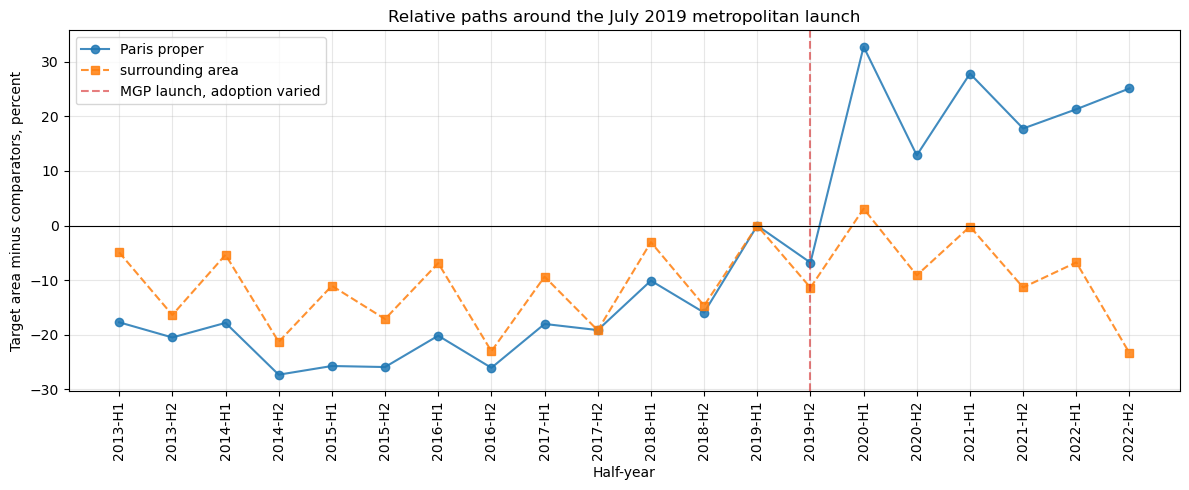

In [35]:
zone_path = "data/interim/panel_zonewide.pkl"
SURROUNDING_REFERENCE_HALF = "2019-H1"
MGP_LAUNCH_HALF = "2019-H2"


def relative_half_year_path(target, comparators, output_column):
    """Estimate one target-comparator path around a common reference half."""
    target = target.copy()
    target["city"] = "Paris"
    comparators = comparators.copy()
    comparators["city"] = comparators["city"].astype(str)
    data = pd.concat([target, comparators], ignore_index=True, sort=False)
    data = data[data["date"].between(
        pd.Timestamp(PRIMARY_SAMPLE[0]), pd.Timestamp(PRIMARY_SAMPLE[1])
    )].copy()

    half = np.where(data["date"].dt.month <= 6, "H1", "H2")
    data["half"] = data["date"].dt.year.astype(str) + "-" + half
    data["is_target"] = (data["city"] == "Paris").astype(int)
    target_halves = sorted(
        data.loc[data["is_target"] == 1, "half"].unique()
    )
    if SURROUNDING_REFERENCE_HALF not in target_halves:
        raise ValueError("2019-H1 is unavailable for the target series")

    def path_term(half_year):
        return "area_" + half_year.replace("-", "_")

    for half_year in target_halves:
        if half_year != SURROUNDING_REFERENCE_HALF:
            data[path_term(half_year)] = (
                data["is_target"] * (data["half"] == half_year).astype(int)
            )

    terms = [
        path_term(half_year) for half_year in target_halves
        if half_year != SURROUNDING_REFERENCE_HALF
    ]
    formula = (
        "log_pm25 ~ 1 + " + " + ".join(terms)
        + " + EntityEffects + TimeEffects"
    )
    fitted = fit_panel(data, formula)

    return pd.DataFrame([{
        "half_year": half_year,
        output_column: (
            0.0 if half_year == SURROUNDING_REFERENCE_HALF
            else round(pct(fitted.params.get(path_term(half_year), np.nan)), 3)
        ),
    } for half_year in target_halves])


if os.path.exists(zone_path):
    zone = pd.read_pickle(zone_path)
    value_column = "pm25_observed" if MODE == "raw" else "pm25"
    required = {"station", "city", "ym", value_column}
    missing = required - set(zone.columns)
    if missing:
        raise ValueError(f"surrounding-area panel is missing {sorted(missing)}")

    z = zone.copy()
    z["date"] = z["ym"].dt.to_timestamp()
    z["analysis_pm25"] = z[value_column]
    if z["analysis_pm25"].isna().any() or (z["analysis_pm25"] <= 0).any():
        raise ValueError("surrounding-area PM2.5 must be positive and complete")
    z["log_pm25"] = np.log(z["analysis_pm25"])

    comparators = panel[(panel["tier"] == "attribution")
                        & (panel["city"] != "Paris")].copy()
    paris_proper = panel[(panel["tier"] == "attribution")
                          & (panel["city"] == "Paris")].copy()

    proper_path = relative_half_year_path(
        paris_proper, comparators, "paris_proper_pct"
    )
    surrounding_path = relative_half_year_path(
        z, comparators, "surrounding_area_pct"
    )
    path_comparison = proper_path.merge(
        surrounding_path, on="half_year", how="inner"
    ).sort_values("half_year").reset_index(drop=True)
    path_comparison["difference"] = (
        path_comparison["surrounding_area_pct"]
        - path_comparison["paris_proper_pct"]
    ).round(3)
    path_comparison["period"] = np.select(
        [
            path_comparison["half_year"] < SURROUNDING_REFERENCE_HALF,
            path_comparison["half_year"] == SURROUNDING_REFERENCE_HALF,
            path_comparison["half_year"] == MGP_LAUNCH_HALF,
        ],
        ["before launch", "reference", "launch half"],
        default="after launch",
    )
    log.table("exploratory_surrounding_area_path", path_comparison)

    after_launch = path_comparison[
        path_comparison["half_year"] >= MGP_LAUNCH_HALF
    ]
    print(
        "\nDescriptive means from the launch half onward: Paris proper "
        f"{after_launch['paris_proper_pct'].mean():+.2f} percent, "
        f"surrounding area {after_launch['surrounding_area_pct'].mean():+.2f} "
        "percent. These are path summaries, not treatment effects."
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(
        path_comparison["half_year"],
        path_comparison["paris_proper_pct"],
        "o-",
        label="Paris proper",
        alpha=0.85,
    )
    ax.plot(
        path_comparison["half_year"],
        path_comparison["surrounding_area_pct"],
        "s--",
        label="surrounding area",
        alpha=0.85,
    )
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(
        MGP_LAUNCH_HALF,
        color="tab:red",
        ls="--",
        alpha=0.6,
        label="MGP launch, adoption varied",
    )
    ax.set_xlabel("Half-year")
    ax.set_ylabel("Target area minus comparators, percent")
    ax.set_title("Relative paths around the July 2019 metropolitan launch")
    ax.tick_params(axis="x", rotation=90)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Surrounding-area panel not found; this diagnostic cannot be computed.")


## P3. Reading the exploratory checks

The leave-one-out table shows whether one station has unusual influence. The second graph compares the Paris-proper and surrounding-area paths around the July 2019 metropolitan launch. It does not assume that every surrounding commune adopted at that date. These checks should be described as exploratory and should not be used to select a preferred estimate after seeing the results.


In [36]:
check_rows = []
for label, sample in [
    ("S1", base_sample[base_sample["station"] != "FR20046"]),
    ("S3", base_sample[base_sample["station"].isin(
        [station for values in ANCHORS_ATTRIB.values() for station in values]
    )]),
]:
    fitted = fit_panel(sample, PRIMARY_FORMULA)
    check_rows.append({
        "sensitivity": label,
        "estimate_pct_full_precision": pct(fitted.params["paris_post"]),
        "station_months": len(sample),
        "stations": sample["station"].nunique(),
    })

log.table("s1_s3_reproducibility_check", pd.DataFrame(check_rows))
log.write()



=== s1_s3_reproducibility_check ===
sensitivity  estimate_pct_full_precision  station_months  stations
         S1                    13.449054             407         8
         S3                    13.448616             332         4

Results written to results/reported
